In [1]:
import random
import logging
import numpy as np
import os
import re
import nibabel as nib
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy
from tqdm.auto import tqdm
import itertools
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from osl_dynamics.data import Data
from osl_dynamics.data import processing
from osl_dynamics.models.hmm import Config
from osl_dynamics.models.hmm import Model
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes

# Prepare Data

In [2]:
# Silence unnecessary messages
_logger = logging.getLogger("osl-dynamics")
_logger.setLevel(logging.CRITICAL + 1)

In [3]:
# Load data
data_prep_method = 'ICA' # PCA, ICA, etc.
if data_prep_method == 'PCA':
    # data_path = '../../CIMT_data/no_wm/LLstim_timecourse_csv_no_wm' # rsfMRI ROI time course CSVs
    # data_path = '../../CIMT_data/no_wm/LLstim_timecourse_csv_no_wm_z_scored' # the already-standardized version, though osl-dynamics already supports standardization
    subj_order = []
    X = []
    y = []
    for tc in sorted(os.listdir(data_path)):
        subj_order.append(tc[:-4])
        X.append(np.loadtxt(os.path.join(data_path, tc), delimiter=','))
        y.append(tc[:12])
    
    X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
elif data_prep_method == 'ICA':
    data_path = '../../FPI_RS_Share/no_wm/ICA_29c' # rsfMRI ICA timecourses
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    bad_ICs = [1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 26, 29] # 1-based indexing
    X = []
    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-14:-1]
            nii = nib.load(os.path.join(data_path, tc))
            X.append(nii.get_fdata())
            y.append(subj_order[i][:3] + '_' + subj_order[i][-4:])
            i += 1
    
    X = np.array(X) # X.shape = (subjects, timepoints, ROIs)
    X = np.delete(X, obj=[IC - 1 for IC in bad_ICs], axis=2)

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)

y = np.array(y)
print(X.shape)
print(y.shape)

(58, 450, 17)
(58,)


In [4]:
subj_order

['r13_01fa_PID1',
 'r13_01fa_PID7',
 'r13_01ma_PID1',
 'r13_01ma_PID7',
 'r13_03mc_PID1',
 'r13_03mc_PID7',
 'r13_04fc_PID1',
 'r13_04fc_PID7',
 'r13_05fd_PID1',
 'r13_05fd_PID7',
 'r13_05mb_PID1',
 'r13_05mb_PID7',
 'r13_05md_PID1',
 'r13_05md_PID7',
 'r13_06md_PID1',
 'r13_06md_PID7',
 'shm_01mb_PID1',
 'shm_01mb_PID7',
 'shm_02fa_PID1',
 'shm_02fa_PID7',
 'shm_02fb_PID1',
 'shm_02fb_PID7',
 'shm_02mc_PID1',
 'shm_02mc_PID7',
 'shm_03fb_PID1',
 'shm_03fb_PID7',
 'shm_03fc_PID1',
 'shm_03fc_PID7',
 'shm_03fd_PID1',
 'shm_03fd_PID7',
 'shm_03mb_PID1',
 'shm_03mb_PID7',
 'shm_03md_PID1',
 'shm_03md_PID7',
 'shm_05ma_PID1',
 'shm_05ma_PID7',
 'shm_06fa_PID1',
 'shm_06fa_PID7',
 'veh_02fc_PID1',
 'veh_02fc_PID7',
 'veh_02mb_PID1',
 'veh_02mb_PID7',
 'veh_04fd_PID1',
 'veh_04fd_PID7',
 'veh_04ma_PID1',
 'veh_04ma_PID7',
 'veh_04mc_PID1',
 'veh_04mc_PID7',
 'veh_04md_PID1',
 'veh_04md_PID7',
 'veh_05fa_PID1',
 'veh_05fa_PID7',
 'veh_05fb_PID1',
 'veh_05fb_PID7',
 'veh_05fc_PID1',
 'veh_05fc

In [5]:
print(X[0].shape)
print(np.prod(X[0].shape)) # n_samples = timepoints * subjects

(450, 17)
7650


In [6]:
np.unique(y)

array(['r13_PID1', 'r13_PID7', 'shm_PID1', 'shm_PID7', 'veh_PID1',
       'veh_PID7'], dtype='<U8')

In [7]:
full_data = Data(X)
print(full_data)

Loading files:   0%|          | 0/58 [00:00<?, ?it/s]

Data
 id: 13174820928
 n_sessions: 58
 n_samples: 26100
 n_channels: 17


# Create Folds

In [8]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits)

In [9]:
split_plan = {
    'outer_train': [],
    'outer_test': [],
    'inner_train': [],
    'inner_val': [],
}

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i + 1}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")
    
    outer_train, outer_test, y_train, y_test = X[train_index,], X[test_index,], y[train_index,], y[test_index,]
    
    # Check for even splits within groups  
    print(np.sum(y_test == "r13_PID1") / np.sum(y == "r13_PID1"))
    print(np.sum(y_test == "r13_PID7") / np.sum(y == "r13_PID7"))
    print(np.sum(y_test == "shm_PID1") / np.sum(y == "shm_PID1"))
    print(np.sum(y_test == "shm_PID7") / np.sum(y == "shm_PID7"))
    print(np.sum(y_test == "veh_PID1") / np.sum(y == "veh_PID1"))
    print(np.sum(y_test == "veh_PID7") / np.sum(y == "veh_PID7"))
    
    inner_train, inner_val, y_inner_train, y_inner_val = train_test_split(outer_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
    
    outer_train = Data(outer_train)
    outer_test = Data(outer_test)
    inner_train = Data(inner_train)
    inner_val = Data(inner_val)
    
    if data_prep_method == 'PCA':
        # EVERYTHING WITHIN THE FOLD SHOULD BE IN THE SAME PCA SPACE
        outer_train.prepare({
            "pca": {"n_pca_components": n_pca_components},
            "standardize": {},
        })
        outer_test.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
        inner_train.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
        inner_val.prepare({
            "pca": {"pca_components": outer_train.pca_components},
            "standardize": {},
        })
    elif data_prep_method == 'ICA':
        outer_train.prepare({"standardize": {}})
        outer_test.prepare({"standardize": {}})
        inner_train.prepare({"standardize": {}})
        inner_val.prepare({"standardize": {}})

    split_plan['outer_train'].append(outer_train)
    split_plan['outer_test'].append(outer_test)
    split_plan['inner_train'].append(inner_train)
    split_plan['inner_val'].append(inner_val)

Fold 1:
  Train: index=[ 4  5  6  7  8  9 10 11 12 13 14 15 20 21 22 23 24 25 26 27 28 29 30 31
 32 33 34 35 36 37 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57]
  Test:  index=[ 0  1  2  3 16 17 18 19 38 39 40 41]
0.25
0.25
0.18181818181818182
0.18181818181818182
0.2
0.2


Loading files:   0%|          | 0/46 [00:00<?, ?it/s]

Loading files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading files:   0%|          | 0/36 [00:00<?, ?it/s]

Loading files:   0%|          | 0/10 [00:00<?, ?it/s]

...

Loading files:   0%|          | 0/10 [00:00<?, ?it/s]

Standardize:   0%|          | 0/47 [00:00<?, ?it/s]

Standardize:   0%|          | 0/11 [00:00<?, ?it/s]

Standardize:   0%|          | 0/37 [00:00<?, ?it/s]

Standardize:   0%|          | 0/10 [00:00<?, ?it/s]

# HMM Training

In [10]:
def get_param_combinations(param_grid):
    combinations = itertools.product(*param_grid.values())
    return [dict(zip(param_grid.keys(), combination)) for combination in combinations]

In [11]:
full_data.recommend_model_config()

Recommendation:
  config = Config(
      ...
      sequence_length=200,
      batch_size=29,
      learning_rate=0.01,
      n_epochs=20,
  )
Total number of sequences: 116
Total number of batches/parameter updates: 4


In [12]:
if data_prep_method == 'PCA':
    pkl_suffix = f"PCA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'ICA':
    pkl_suffix = f"ICA_{full_data.n_channels}c_no_TDE"

hyperparam_grid = {
    'sequence_length': [225], # .recommend_model_config() recommends 200, so increase slightly to 225 for clean division of 450
    'batch_size': [29], # osl-dynamics chooses batch_size such that full_data.n_samples // (sequence_length * batch_size) = 4
    'learning_rate': [0.01], 
    'n_epochs': [20, 30, 40, 50, 60, 70, 80, 90, 100], # added more options to check for possible further improvement past 20 epochs
}

print("full_data.n_samples // (sequence_length * batch_size)) =", full_data.n_samples // (hyperparam_grid['sequence_length'][0] * hyperparam_grid['batch_size'][0]))
print(pkl_suffix)

full_data.n_samples // (sequence_length * batch_size)) = 4
ICA_17c_no_TDE


## k-fold CV to Determine Optimal Hyperparameters for Each Number of States

In [13]:
model_eval_log = {}

In [14]:
if os.path.exists(f'grid_search/model_eval_log_{pkl_suffix}.pkl'):
    with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs('grid_search', exist_ok=True)

sorted(model_eval_log.keys())

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [15]:
# CV to determine optimal hyperparameters for each number of states 
min_n_states = 2 # must be >= 2
max_n_states = 20
for num_states in range(min_n_states, max_n_states + 1):
    print(f"\nGrid searching with {num_states} states...")
    if num_states not in model_eval_log:
        model_eval_log[num_states] = {
            'hyperparams': [], # {hyperparams}
            'histories': [], # [history object from best run for each fold]
            'test_free_energies': [], # [float]
        }

    random.seed(42)
    np.random.seed(42)
    i = 1
    for hyperparams in get_param_combinations(hyperparam_grid):
        print(f"Param set {i}: {hyperparams}")
        if hyperparams not in model_eval_log[num_states]['hyperparams']:
            histories = []
            test_free_energies = []
            for f in range(n_splits):
                print(f"\nFold {f + 1}...")
                outer_test, inner_train, inner_val = split_plan['outer_test'][f], split_plan['inner_train'][f], split_plan['inner_val'][f]
                config = Config(
                    n_states=num_states,
                    n_channels=inner_train.n_channels,
                    sequence_length=hyperparams['sequence_length'],
                    learn_means=False,
                    learn_covariances=True,
                    batch_size=hyperparams['batch_size'],
                    learning_rate=hyperparams['learning_rate'],
                    n_epochs=hyperparams['n_epochs'],
                )
                
                model = Model(config)
                model.random_state_time_course_initialization(inner_train, verbose=0) # n_epochs defaults to 1 and n_init defaults to 3
                callback = EarlyStopping(monitor='val_loss', patience=5, verbose=0) # we don't need restore_best_weights=True because we aren't saving the models
                history = model.fit(
                    inner_train,
                    validation_data=inner_val.dataset(
                        sequence_length=hyperparams['sequence_length'],
                        batch_size=hyperparams['batch_size'],
                    ),
                    verbose=0,
                    callbacks=[callback],
                )
                    
                histories.append(history)
                        
                test_free_energy = model.free_energy(outer_test)
                test_free_energies.append(test_free_energy)
    
            model_eval_log[num_states]['hyperparams'].append(hyperparams)
            model_eval_log[num_states]['histories'].append(histories)
            model_eval_log[num_states]['test_free_energies'].append(test_free_energies) # can take the mean across folds later
        else:
            print(f"Param set {i} has already been evaluated, skipping...")
        
        i += 1

    with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'wb') as f:
        pickle.dump(model_eval_log, f)


Grid searching with 2 states...
Param set 1: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 20}
Param set 1 has already been evaluated, skipping...
Param set 2: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 30}
Param set 2 has already been evaluated, skipping...
Param set 3: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 40}
Param set 3 has already been evaluated, skipping...
Param set 4: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 50}
Param set 4 has already been evaluated, skipping...
Param set 5: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 60}
Param set 5 has already been evaluated, skipping...
Param set 6: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 70}
Param set 6 has already been evaluated, skipping...
Param set 7: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epo

2026-01-03 06:20:03.461637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-03 06:20:07.467862: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-01-03 06:20:19 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 5 out of the last 13 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x31c635580> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]

2026-01-03 06:20:24.659206: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 4...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5...


Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
sorted_states = sorted(model_eval_log.keys())
sorted_states

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

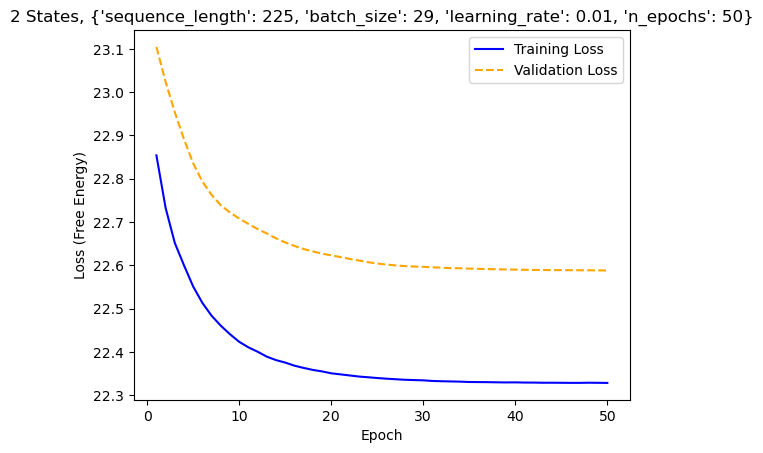

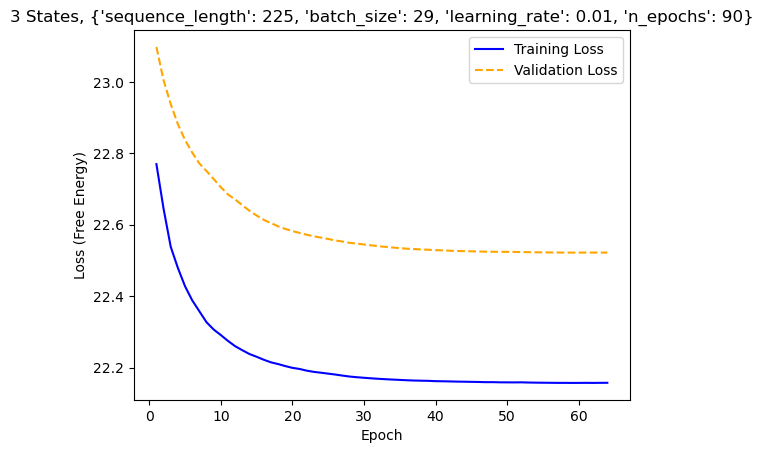

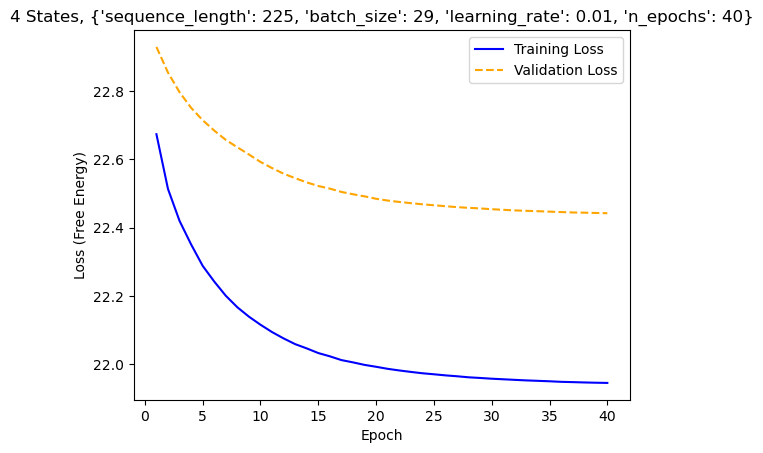

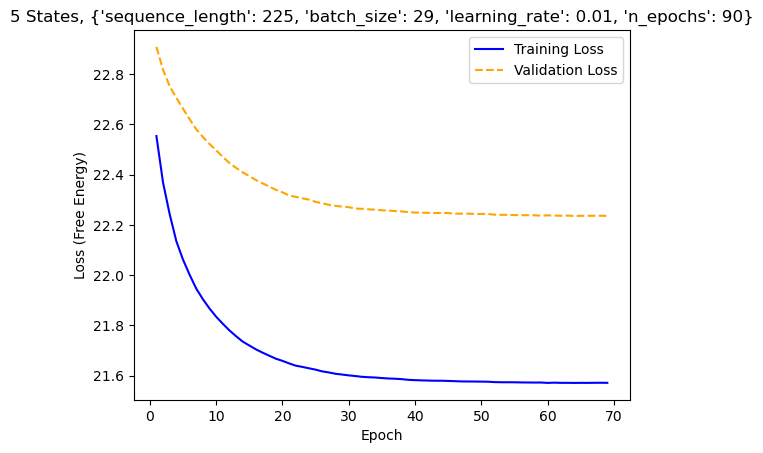

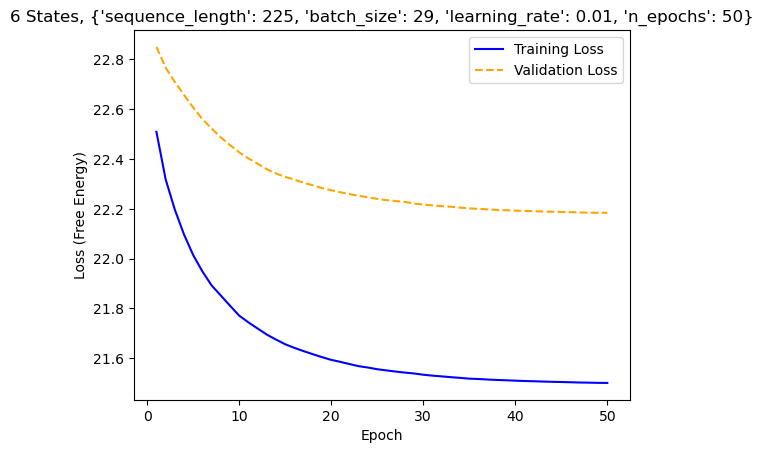

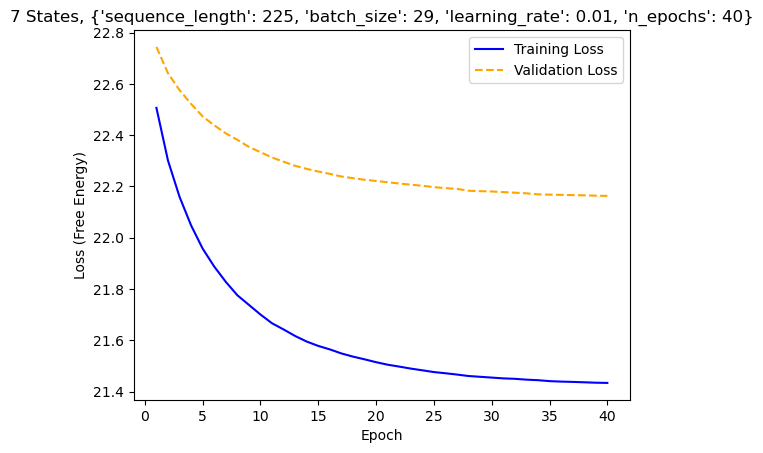

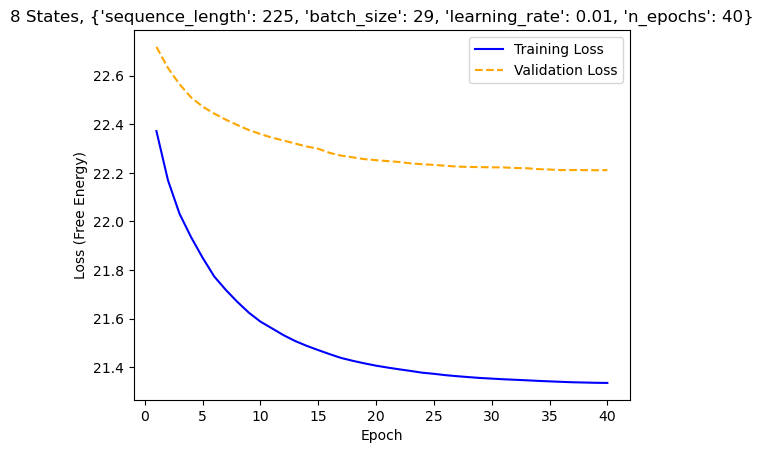

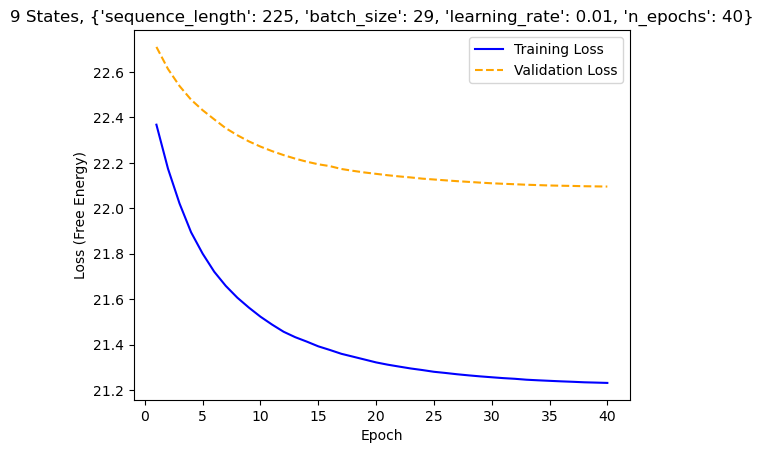

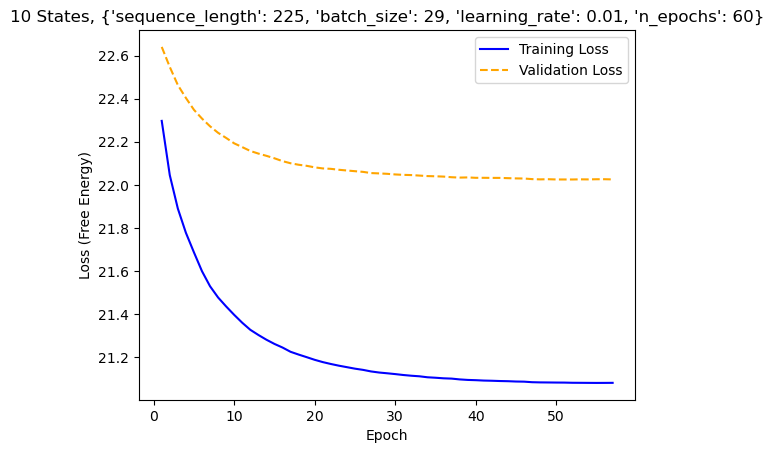

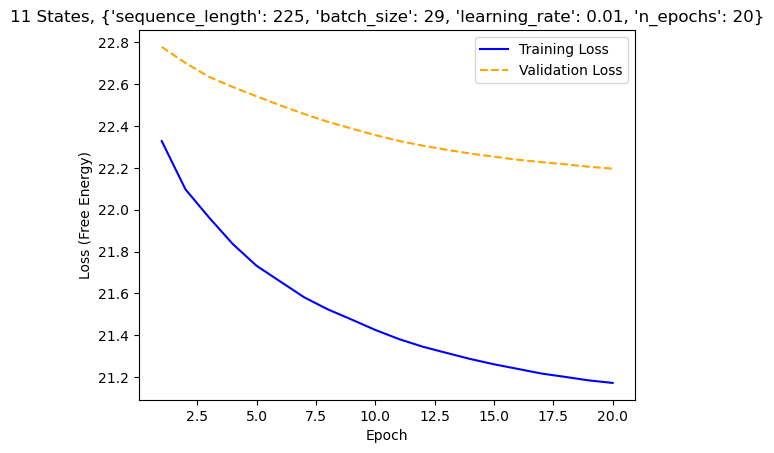

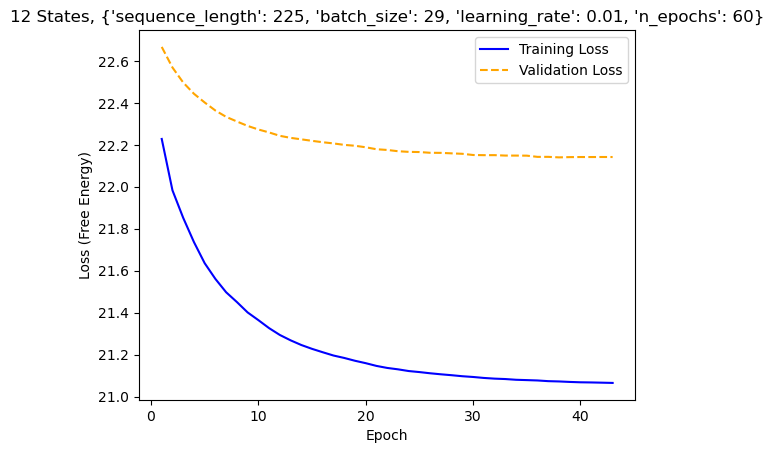

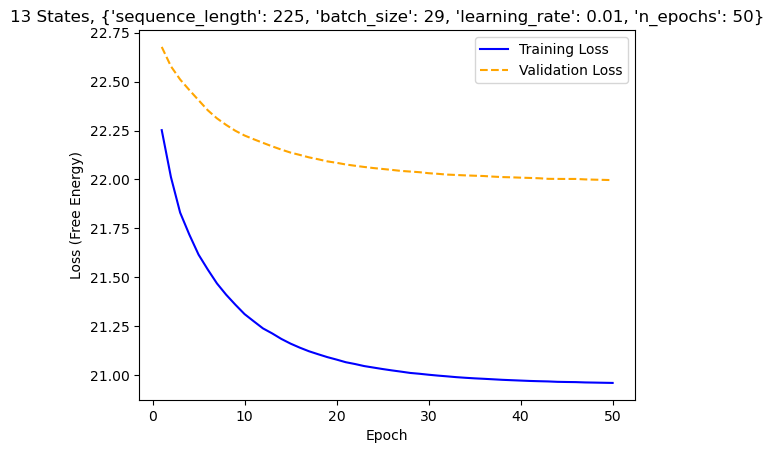

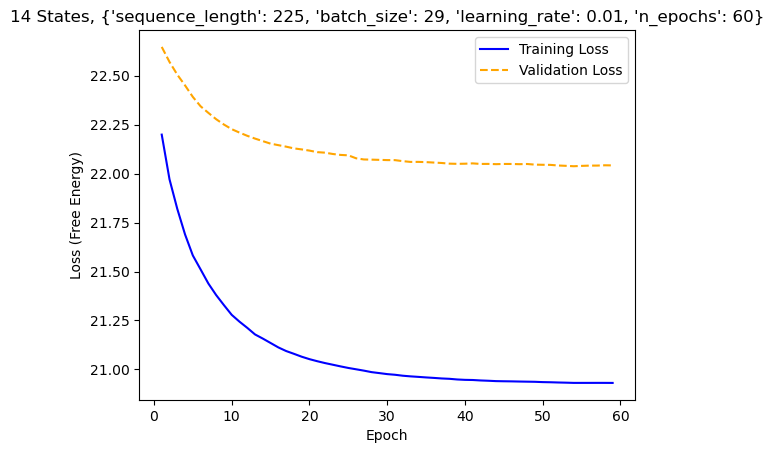

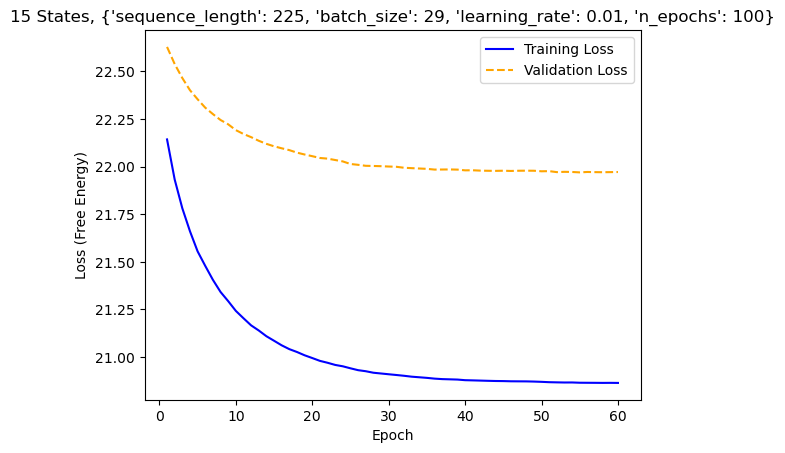

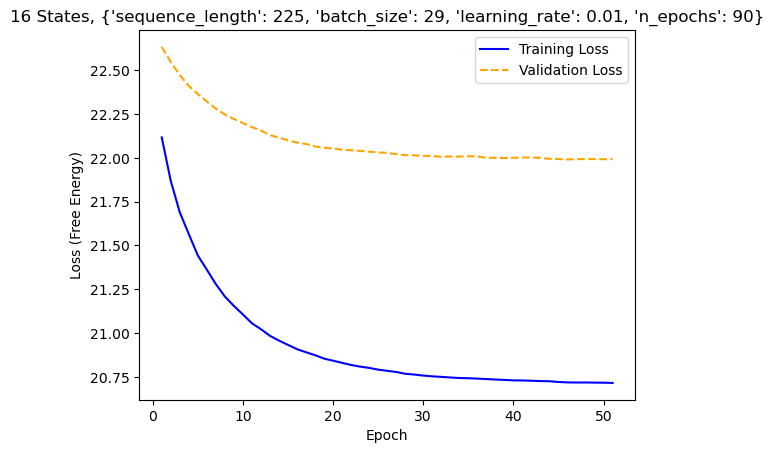

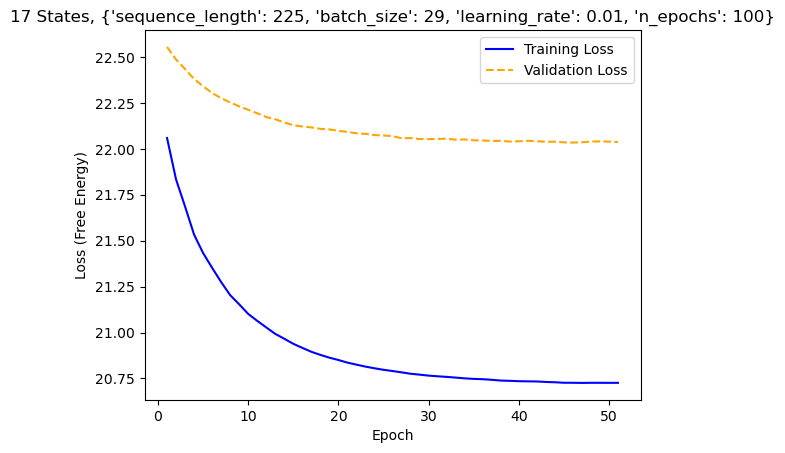

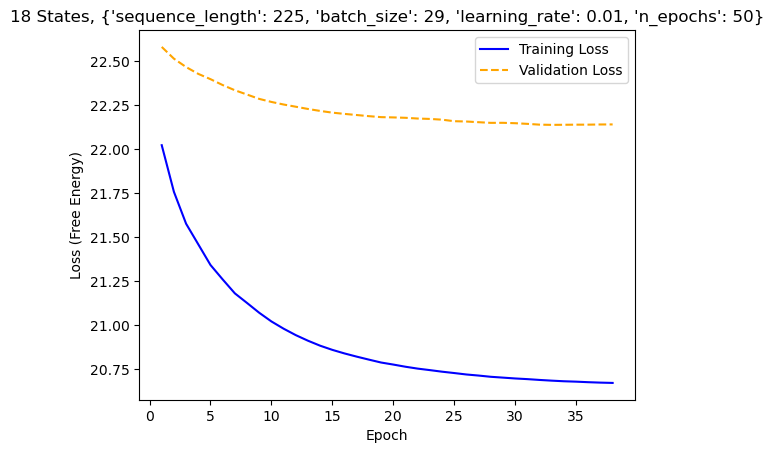

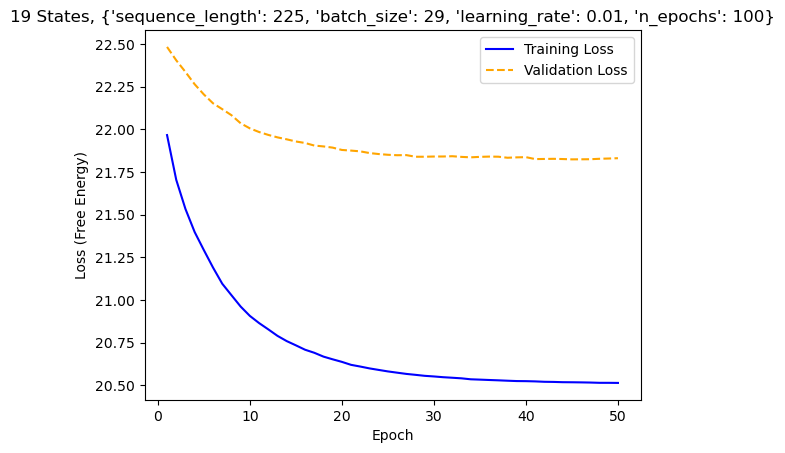

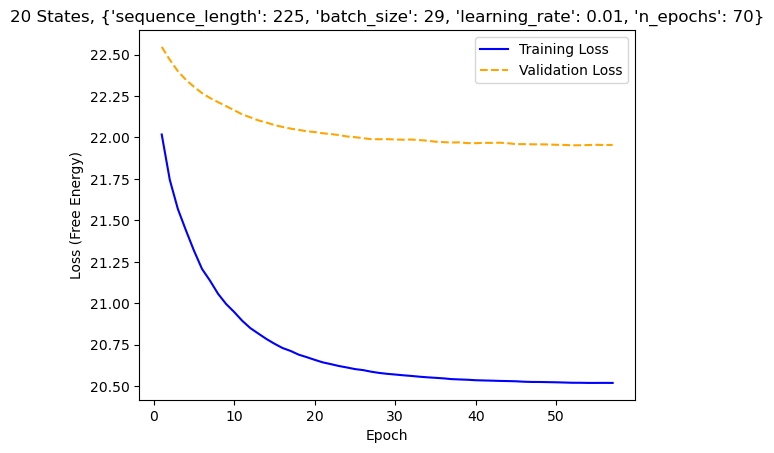

In [17]:
# Sanity check
f_idx = 0
for num_states in sorted_states:
    example = model_eval_log[num_states]['histories'][np.argmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]
    fig, ax = plt.subplots(1, 1)
    x = range(1, len(example[f_idx]['loss']) + 1)
    ax.plot(x, example[f_idx]['loss'], label="Training Loss", color='blue', linestyle='-')
    ax.plot(x, example[f_idx]['val_loss'], label="Validation Loss", color='orange', linestyle='--')

    ax.set_title(f"{num_states} States, " + str(model_eval_log[num_states]['hyperparams'][np.argmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Free Energy)")
    ax.legend()
    plt.show()

In [18]:
for num_states in sorted_states:
    print(f"Best params for {num_states} states: {model_eval_log[num_states]['hyperparams'][np.argmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]}")

Best params for 2 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 3 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 90}
Best params for 4 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 5 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 90}
Best params for 6 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 50}
Best params for 7 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 8 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 9 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 40}
Best params for 10 states: {'sequence_length': 225, 'batch_size': 29, 'learning_rate': 0.01, 'n_epochs': 60}
Best params for 11 states: 

## Compute Model Evaluation Metrics on the Full Dataset for Each Number of States

In [19]:
num_realizations = 10
results_path = f'results/{pkl_suffix}'
os.makedirs(results_path, exist_ok=True) # don't worry, os.makedirs() never replaces a directory (or parent directory) if it already exists

In [20]:
# Compute full-dataset evaluation metrics
for num_states in sorted_states:
    print(f"Fitting model with {num_states} states...")
    if 'realizations' not in model_eval_log[num_states]:
        model_eval_log[num_states]['realizations'] = []
        realizations = [] # contains model object from each realization. Models can't be pickled, so we will pick the best realization and save the corresponding model object separately
        model_eval_log[num_states]['free_energy'] = []
        model_eval_log[num_states]['full_LL'] = []
        model_eval_log[num_states]['BIC'] = []
        model_eval_log[num_states]['MMDL'] = []
        random.seed(42)
        np.random.seed(42)
        for r in range(num_realizations): # account for variability in .random_state_time_course_initialization(), then average later
            print(f"Realization {r + 1}:")
            model_eval_log[num_states]['realizations'].append({})
            best_hyperparams = model_eval_log[num_states]['hyperparams'][np.argmin(np.mean(model_eval_log[num_states]['test_free_energies'], axis=1))]
            config = Config(
                n_states=num_states,
                n_channels=full_data.n_channels,
                sequence_length=best_hyperparams['sequence_length'],
                learn_means=False,
                learn_covariances=True,
                batch_size=best_hyperparams['batch_size'],
                learning_rate=best_hyperparams['learning_rate'],
                n_epochs=best_hyperparams['n_epochs'],
                loss_calc='mean', # to get the average per-timepoint log likelihood when computing test evidence
            )
    
            model = Model(config)
            model.random_state_time_course_initialization(full_data, verbose=0)
            history = model.fit(full_data, verbose=0)
            realizations.append(model)
            
            free_energy = model.free_energy(full_data) # note that .free_energy() returns the free energy averaged over batches
            model_eval_log[num_states]['free_energy'].append(free_energy)
    
            _, covs = model.get_means_covariances() # learn_means=False so means will be zero 
            model_eval_log[num_states]['realizations'][r]['covs'] = covs
        
            off_diags = []
            dofs = [] # degrees of freedom of inverse covariance matrices (precision matrices), used to compute MMDL
            for cov in covs:
                ut = np.triu(cov, k=1) # upper triange, excluding main diagonal
                off_diag = ut[ut != 0]
                off_diags.append(off_diag)
    
                precision_matrix = np.linalg.inv(cov)
                precision_matrix_ut = np.triu(precision_matrix) # upper triangle, incuding main diagonal
                dofs.append(np.sum(precision_matrix_ut != 0)) # "Df(k) is the number of non-zeroes in the precision matrix"
        
            model_eval_log[num_states]['realizations'][r]['off_diags'] = np.array(off_diags).T
            
            mean_per_timepoint_LL = model.evidence(full_data)
            full_LL = mean_per_timepoint_LL * full_data.n_samples
            model_eval_log[num_states]['full_LL'].append(full_LL)
        
            # Compute Bayesian Information Criterion (BIC)
            d = full_data.n_channels
            k = (num_states - 1) + num_states * (num_states - 1) + num_states * (d * (d + 1)) / 2 # number of estimated parameters, learn_means=False
            BIC = k * np.log(full_data.n_samples) - 2 * full_LL
            model_eval_log[num_states]['BIC'].append(BIC)
    
            # Compute Mixture Minimum Description Length (MMDL) 
            alpha = np.array(model.get_alpha(full_data)) # state probability time courses for each subject (subjects x timepoints x num_states)
            third_term = np.sum([np.log(full_data.n_samples * np.sum(alpha[:, :, state_num])) * dofs[state_num] for state_num in range(num_states)]) / 2
            MMDL = -full_LL + np.log(full_data.n_samples) * num_states * (num_states - 1) / 2 + third_term
            model_eval_log[num_states]['MMDL'].append(MMDL)
        
        model_dir = f'{results_path}/{num_states}_states'
        os.makedirs(model_dir, exist_ok=True)
        best_realization_path = f'{model_dir}/{num_states}_states_model'
        realizations[np.argmin(model_eval_log[num_states]['MMDL'])].save(best_realization_path) # save model object with lowest MMDL
        model_eval_log[num_states]['best_realization_path'] = best_realization_path
        with open(f'grid_search/model_eval_log_{pkl_suffix}.pkl', 'wb') as f:
            pickle.dump(model_eval_log, f)
    else:
        print(f"The model with {num_states} states has already been evaluated on the full dataset, skipping...")

Fitting model with 2 states...
Realization 1:


Getting free energy:   0%|          | 0/4 [00:00<?, ?it/s]

Getting evidence:   0%|          | 0/4 [00:00<?, ?it/s]

Getting alpha:   0%|          | 0/58 [00:00<?, ?it/s]

Realization 2:


...

Getting alpha:   0%|          | 0/58 [00:00<?, ?it/s]

Realization 10:


Getting free energy:   0%|          | 0/4 [00:00<?, ?it/s]

Getting evidence:   0%|          | 0/4 [00:00<?, ?it/s]

Getting alpha:   0%|          | 0/58 [00:00<?, ?it/s]

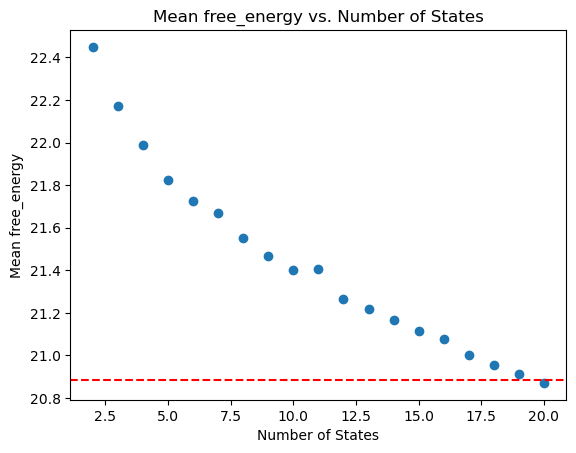

num_states: free_energy
20: 20.871163847020036
19: 20.915331988704395
18: 20.953487641490835
17: 21.002342243801202
16: 21.07709723911533
15: 21.11593581233973
14: 21.16649987750666
13: 21.2196737683042
12: 21.26430343589653
10: 21.402659811799047
11: 21.405099408013765
9: 21.468755401266858
8: 21.553057901669202
7: 21.669563794772138
6: 21.726862454639807
5: 21.823519438623222
4: 21.99069084076282
3: 22.170959229692496
2: 22.449014846694165


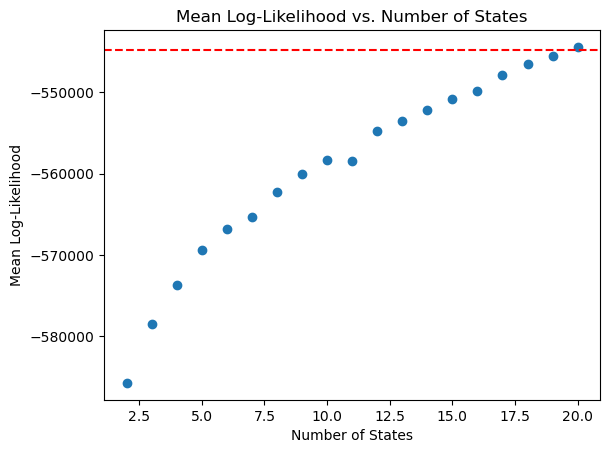

num_states: full_LL
2: -585780.875
3: -578496.875
4: -573768.3125
5: -569386.1875
6: -566846.9375
7: -565337.5
8: -562284.25
9: -560073.0625
11: -558392.125
10: -558337.4375
12: -554708.625
13: -553535.0
14: -552140.6875
15: -550814.875
16: -549793.4375
17: -547835.0
18: -546556.125
19: -545554.6875
20: -544397.125


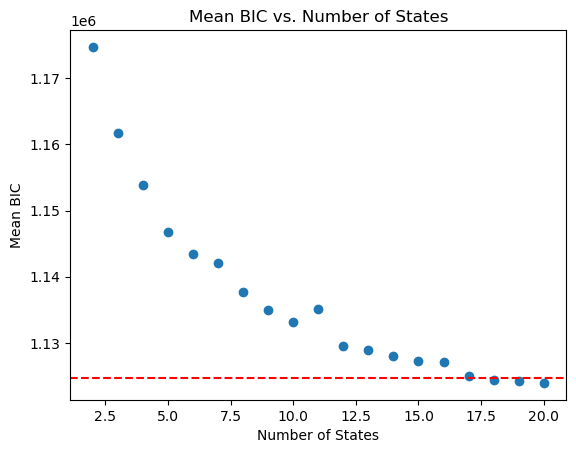

num_states: BIC
20: 1123971.184762262
19: 1124333.6916683463
18: 1124404.3504556173
17: 1125050.2986240746
16: 1127075.7111737193
15: 1127247.28810455
14: 1128047.9669165672
13: 1129006.0726097715
12: 1129542.905184162
10: 1133241.4134765032
9: 1134963.276694454
11: 1135120.2021397394
8: 1137656.8792935908
7: 1142054.896273915
6: 1143385.665135425
5: 1146796.360878122
4: 1153912.9835020057
3: 1161743.008007076
2: 1174704.1468933332


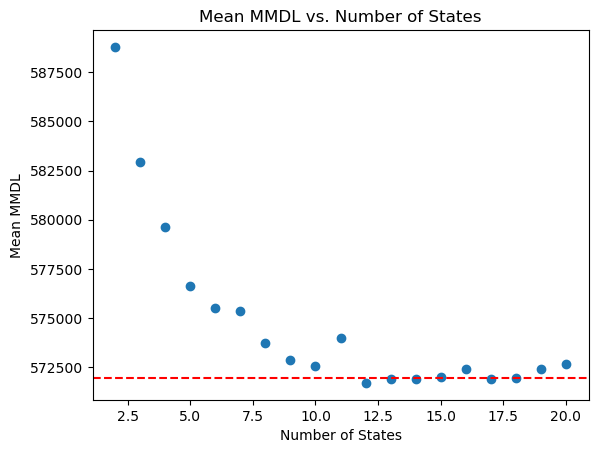

num_states: MMDL
12: 571689.881564541
17: 571866.3796386811
14: 571903.9730942423
13: 571907.7435158448
18: 571961.5706792324
15: 571993.008031694
16: 572377.0907274077
19: 572405.3791183658
10: 572527.6769595259
20: 572677.363958172
9: 572875.1985793959
8: 573705.4244083265
11: 573970.6920739749
7: 575366.4415271896
6: 575490.4144733181
5: 576637.222898252
4: 579621.8168579768
3: 582936.4069443918
2: 588796.7483538704


In [21]:
metrics = ['free_energy', 'full_LL', 'BIC', 'MMDL']
for metric in metrics:
    one_se_rule = {}
    
    for key, value in model_eval_log.items():
        one_se_rule[key] = {
            'mean': np.mean(value[metric]),
            'se': np.std(value[metric], ddof=1) / np.sqrt(num_realizations),
        }

    sorted_by_mean = sorted(list(one_se_rule.items()), key=lambda x: x[1]['mean'])
    
    fig, ax = plt.subplots(1, 1)
    num_states_list = [x[0] for x in sorted_by_mean]
    means = [x[1]['mean'] for x in sorted_by_mean]
    ax.scatter(num_states_list, means)
    if metric == 'full_LL':
        ax.axhline(y=sorted_by_mean[-1][1]['mean'] - sorted_by_mean[-1][1]['se'], color='r', linestyle='--')
        ax.set_title("Mean Log-Likelihood vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel("Mean Log-Likelihood")
    else:
        ax.axhline(y=sorted_by_mean[0][1]['mean'] + sorted_by_mean[0][1]['se'], color='r', linestyle='--')
        ax.set_title(f"Mean {metric} vs. Number of States")
        ax.set_xlabel("Number of States")
        ax.set_ylabel(f"Mean {metric}")
    plt.show()

    print(f"num_states: {metric}")
    for num_states in num_states_list:
        print(f"{num_states}: {np.mean(model_eval_log[num_states][metric])}")

In [22]:
def realization_corr(r1, r2):
    r1_stan = (r1 - np.mean(r1, axis=0, keepdims=True)) / np.std(r1, axis=0, keepdims=True)
    r2_stan = (r2 - np.mean(r2, axis=0, keepdims=True)) / np.std(r2, axis=0, keepdims=True)

    return r1_stan.T @ r2_stan / (r1_stan.shape[0] - 1)


Aligned States for n_states=2:

Aligned State 1:
Realization 1, state 1
Realization 2, state 1
Realization 3, state 1
Realization 4, state 2
Realization 5, state 2
Realization 6, state 2
Realization 7, state 2
Realization 8, state 1
Realization 9, state 2
Realization 10, state 1
Average between-realization correlation: 0.9977485859325372

Aligned State 2:
Realization 1, state 2
Realization 2, state 2
Realization 3, state 2
Realization 4, state 1
Realization 5, state 1
Realization 6, state 1
Realization 7, state 1
Realization 8, state 2
Realization 9, state 1
Realization 10, state 2
Average between-realization correlation: 0.9960677681283193


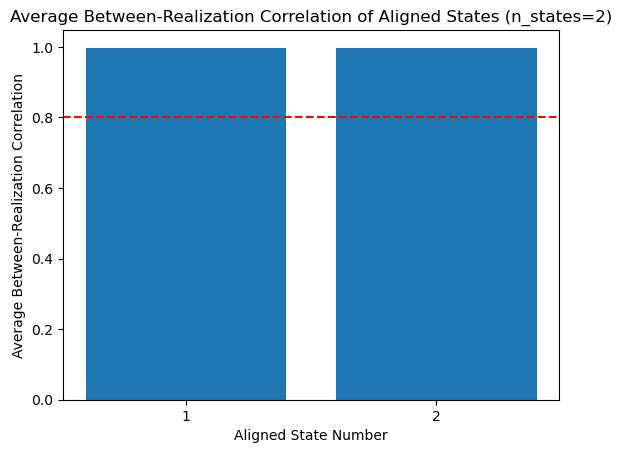


Aligned States for n_states=3:

Aligned State 1:
Realization 1, state 2
Realization 2, state 3
Realization 3, state 1
Realization 4, state 3
Realization 5, state 1
Realization 6, state 3
Realization 7, state 1
Realization 8, state 3
Realization 9, state 3
Realization 10, state 2
Average between-realization correlation: 0.977443952863127

Aligned State 2:
Realization 1, state 3
Realization 2, state 1
Realization 3, state 2
Realization 4, state 1
Realization 5, state 2
Realization 6, state 2
Realization 7, state 2
Realization 8, state 2
Realization 9, state 2
Realization 10, state 3
Average between-realization correlation: 0.9168808794594681

Aligned State 3:
Realization 1, state 1
Realization 2, state 2
Realization 3, state 3
Realization 4, state 2
Realization 5, state 3
Realization 6, state 1
Realization 7, state 3
Realization 8, state 1
Realization 9, state 1
Realization 10, state 1
Average between-realization correlation: 0.7821232592658365


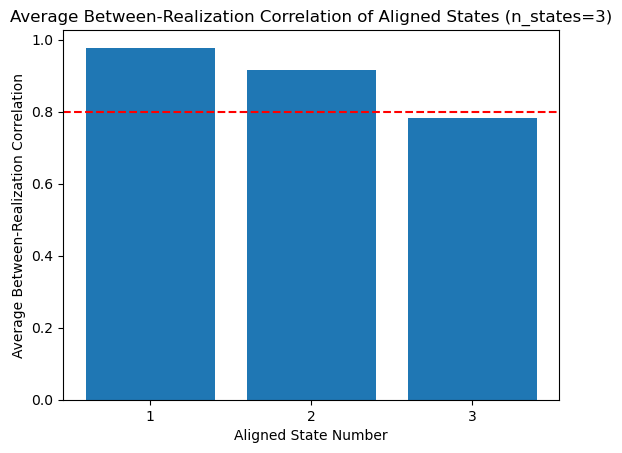


Aligned States for n_states=4:

Aligned State 1:
Realization 1, state 2
Realization 2, state 2
Realization 3, state 4
Realization 4, state 1
Realization 5, state 2
Realization 6, state 3
Realization 7, state 1
Realization 8, state 4
Realization 9, state 2
Realization 10, state 3
Average between-realization correlation: 0.9717511133542255

Aligned State 2:
Realization 1, state 1
Realization 2, state 3
Realization 3, state 3
Realization 4, state 3
Realization 5, state 1
Realization 6, state 1
Realization 7, state 2
Realization 8, state 2
Realization 9, state 1
Realization 10, state 2
Average between-realization correlation: 0.930674091444862

Aligned State 3:
Realization 1, state 4
Realization 2, state 4
Realization 3, state 2
Realization 4, state 4
Realization 5, state 4
Realization 6, state 2
Realization 7, state 3
Realization 8, state 3
Realization 9, state 4
Realization 10, state 1
Average between-realization correlation: 0.9246781218747366

Aligned State 4:
Realization 1, state 3
R

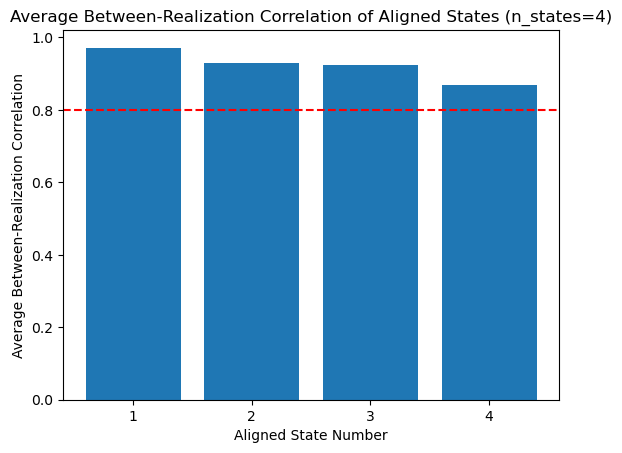


Aligned States for n_states=5:

Aligned State 1:
Realization 1, state 4
Realization 2, state 2
Realization 3, state 5
Realization 4, state 3
Realization 5, state 5
Realization 6, state 2
Realization 7, state 5
Realization 8, state 3
Realization 9, state 1
Realization 10, state 4
Average between-realization correlation: 0.9586287762434793

Aligned State 2:
Realization 1, state 3
Realization 2, state 4
Realization 3, state 4
Realization 4, state 1
Realization 5, state 3
Realization 6, state 5
Realization 7, state 2
Realization 8, state 5
Realization 9, state 5
Realization 10, state 2
Average between-realization correlation: 0.9209857787503813

Aligned State 3:
Realization 1, state 1
Realization 2, state 1
Realization 3, state 2
Realization 4, state 4
Realization 5, state 1
Realization 6, state 4
Realization 7, state 1
Realization 8, state 1
Realization 9, state 2
Realization 10, state 5
Average between-realization correlation: 0.9052323079233323

Aligned State 4:
Realization 1, state 2


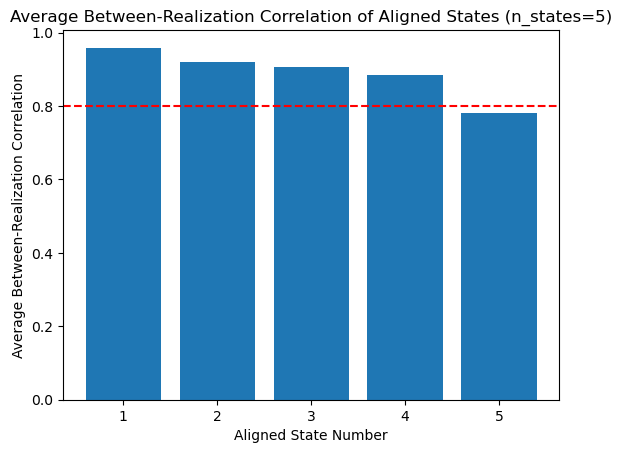


Aligned States for n_states=6:

Aligned State 1:
Realization 1, state 6
Realization 2, state 1
Realization 3, state 5
Realization 4, state 1
Realization 5, state 5
Realization 6, state 3
Realization 7, state 2
Realization 8, state 5
Realization 9, state 2
Realization 10, state 1
Average between-realization correlation: 0.9796567080009988

Aligned State 2:
Realization 1, state 4
Realization 2, state 3
Realization 3, state 1
Realization 4, state 6
Realization 5, state 1
Realization 6, state 1
Realization 7, state 6
Realization 8, state 4
Realization 9, state 5
Realization 10, state 5
Average between-realization correlation: 0.9459415841159546

Aligned State 3:
Realization 1, state 2
Realization 2, state 4
Realization 3, state 6
Realization 4, state 5
Realization 5, state 4
Realization 6, state 2
Realization 7, state 5
Realization 8, state 6
Realization 9, state 4
Realization 10, state 6
Average between-realization correlation: 0.9210756889000611

Aligned State 4:
Realization 1, state 3


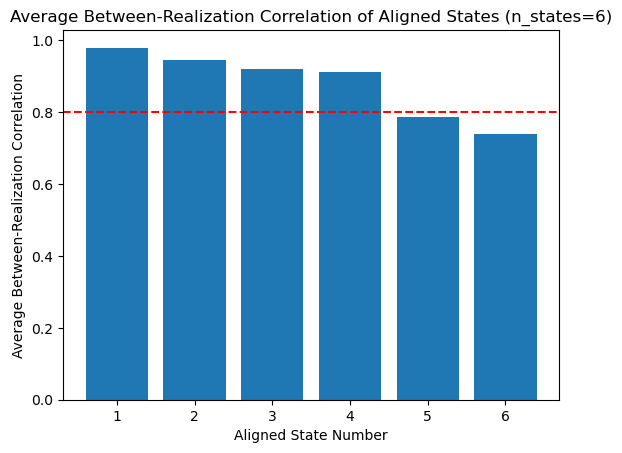


Aligned States for n_states=7:

Aligned State 1:
Realization 1, state 1
Realization 2, state 5
Realization 3, state 1
Realization 4, state 3
Realization 5, state 3
Realization 6, state 3
Realization 7, state 4
Realization 8, state 3
Realization 9, state 4
Realization 10, state 1
Average between-realization correlation: 0.9598859002008916

Aligned State 2:
Realization 1, state 4
Realization 2, state 3
Realization 3, state 6
Realization 4, state 5
Realization 5, state 7
Realization 6, state 7
Realization 7, state 6
Realization 8, state 6
Realization 9, state 2
Realization 10, state 4
Average between-realization correlation: 0.9250786654145468

Aligned State 3:
Realization 1, state 3
Realization 2, state 1
Realization 3, state 4
Realization 4, state 4
Realization 5, state 4
Realization 6, state 2
Realization 7, state 5
Realization 8, state 5
Realization 9, state 1
Realization 10, state 2
Average between-realization correlation: 0.9226423128803763

Aligned State 4:
Realization 1, state 7


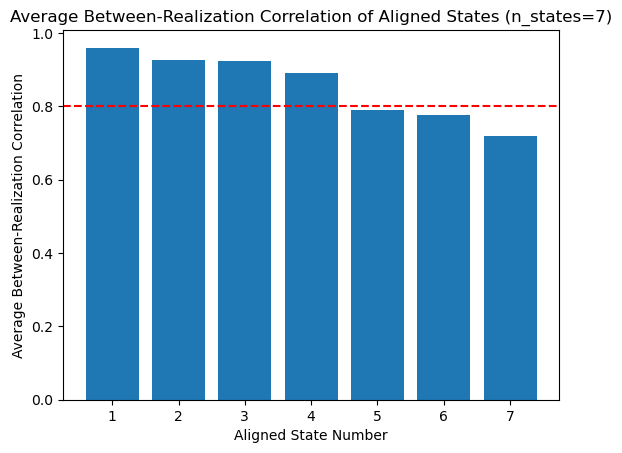


Aligned States for n_states=8:

Aligned State 1:
Realization 1, state 3
Realization 2, state 3
Realization 3, state 5
Realization 4, state 4
Realization 5, state 5
Realization 6, state 8
Realization 7, state 8
Realization 8, state 8
Realization 9, state 8
Realization 10, state 1
Average between-realization correlation: 0.9621302049721568

Aligned State 2:
Realization 1, state 4
Realization 2, state 1
Realization 3, state 8
Realization 4, state 7
Realization 5, state 3
Realization 6, state 1
Realization 7, state 5
Realization 8, state 6
Realization 9, state 1
Realization 10, state 4
Average between-realization correlation: 0.9206764248227259

Aligned State 3:
Realization 1, state 2
Realization 2, state 2
Realization 3, state 6
Realization 4, state 5
Realization 5, state 6
Realization 6, state 3
Realization 7, state 3
Realization 8, state 7
Realization 9, state 3
Realization 10, state 6
Average between-realization correlation: 0.9172661704757358

Aligned State 4:
Realization 1, state 6


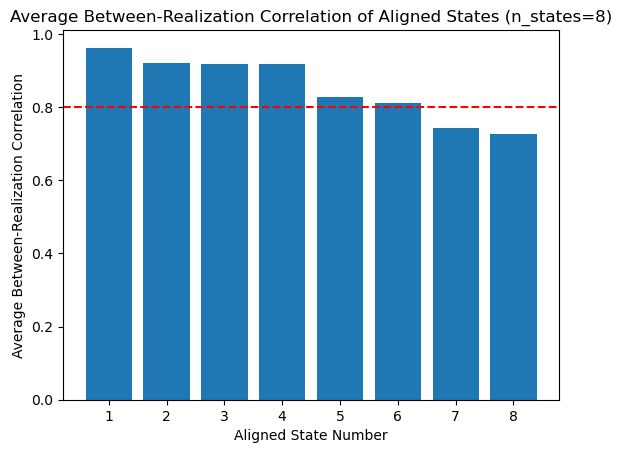


Aligned States for n_states=9:

Aligned State 1:
Realization 1, state 8
Realization 2, state 9
Realization 3, state 4
Realization 4, state 1
Realization 5, state 6
Realization 6, state 4
Realization 7, state 6
Realization 8, state 8
Realization 9, state 6
Realization 10, state 6
Average between-realization correlation: 0.9656415931520053

Aligned State 2:
Realization 1, state 2
Realization 2, state 4
Realization 3, state 8
Realization 4, state 4
Realization 5, state 1
Realization 6, state 5
Realization 7, state 2
Realization 8, state 4
Realization 9, state 3
Realization 10, state 4
Average between-realization correlation: 0.9502820543624306

Aligned State 3:
Realization 1, state 6
Realization 2, state 7
Realization 3, state 3
Realization 4, state 7
Realization 5, state 3
Realization 6, state 1
Realization 7, state 7
Realization 8, state 2
Realization 9, state 1
Realization 10, state 1
Average between-realization correlation: 0.9170619656349135

Aligned State 4:
Realization 1, state 4


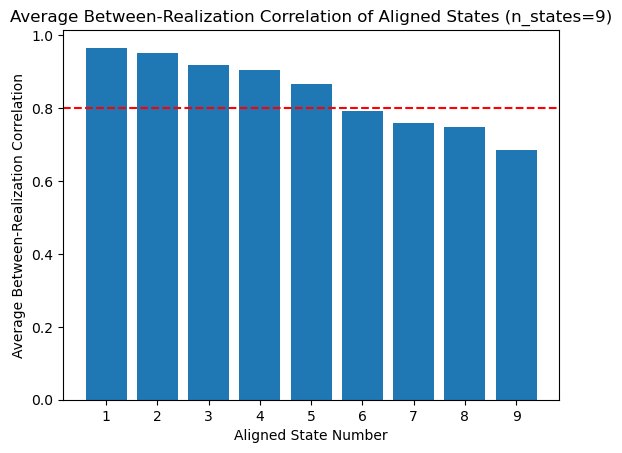


Aligned States for n_states=10:

Aligned State 1:
Realization 1, state 9
Realization 2, state 9
Realization 3, state 7
Realization 4, state 3
Realization 5, state 1
Realization 6, state 4
Realization 7, state 2
Realization 8, state 4
Realization 9, state 5
Realization 10, state 9
Average between-realization correlation: 0.9531141104545001

Aligned State 2:
Realization 1, state 3
Realization 2, state 5
Realization 3, state 10
Realization 4, state 1
Realization 5, state 7
Realization 6, state 8
Realization 7, state 8
Realization 8, state 1
Realization 9, state 4
Realization 10, state 7
Average between-realization correlation: 0.9364802787171915

Aligned State 3:
Realization 1, state 5
Realization 2, state 10
Realization 3, state 9
Realization 4, state 7
Realization 5, state 4
Realization 6, state 6
Realization 7, state 3
Realization 8, state 7
Realization 9, state 2
Realization 10, state 3
Average between-realization correlation: 0.8805258828618082

Aligned State 4:
Realization 1, state

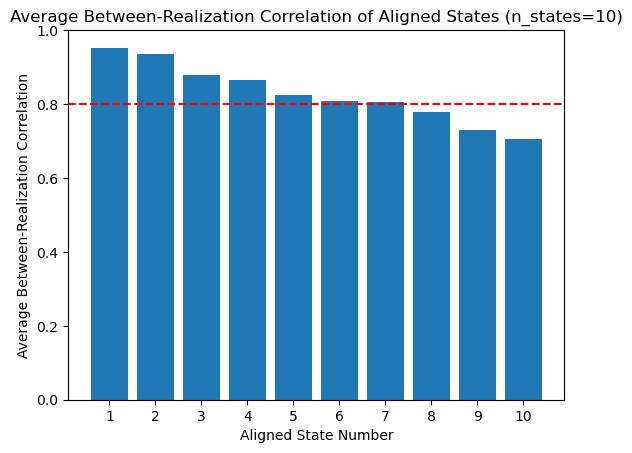


Aligned States for n_states=11:

Aligned State 1:
Realization 1, state 1
Realization 2, state 7
Realization 3, state 11
Realization 4, state 11
Realization 5, state 3
Realization 6, state 8
Realization 7, state 9
Realization 8, state 4
Realization 9, state 9
Realization 10, state 9
Average between-realization correlation: 0.9539533085875866

Aligned State 2:
Realization 1, state 6
Realization 2, state 4
Realization 3, state 5
Realization 4, state 4
Realization 5, state 1
Realization 6, state 5
Realization 7, state 6
Realization 8, state 1
Realization 9, state 4
Realization 10, state 3
Average between-realization correlation: 0.9465579058682146

Aligned State 3:
Realization 1, state 2
Realization 2, state 9
Realization 3, state 9
Realization 4, state 1
Realization 5, state 7
Realization 6, state 4
Realization 7, state 1
Realization 8, state 5
Realization 9, state 11
Realization 10, state 1
Average between-realization correlation: 0.8964944080154459

Aligned State 4:
Realization 1, stat

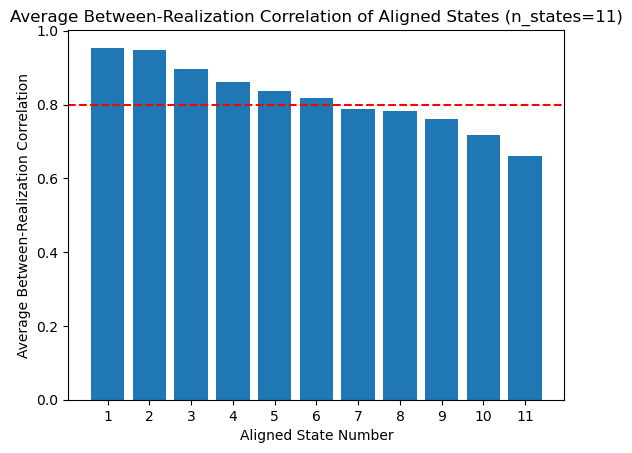


Aligned States for n_states=12:

Aligned State 1:
Realization 1, state 8
Realization 2, state 2
Realization 3, state 8
Realization 4, state 12
Realization 5, state 7
Realization 6, state 2
Realization 7, state 11
Realization 8, state 3
Realization 9, state 7
Realization 10, state 12
Average between-realization correlation: 0.955445266299736

Aligned State 2:
Realization 1, state 5
Realization 2, state 11
Realization 3, state 3
Realization 4, state 2
Realization 5, state 5
Realization 6, state 12
Realization 7, state 8
Realization 8, state 7
Realization 9, state 3
Realization 10, state 8
Average between-realization correlation: 0.9383018775167709

Aligned State 3:
Realization 1, state 10
Realization 2, state 7
Realization 3, state 1
Realization 4, state 1
Realization 5, state 9
Realization 6, state 3
Realization 7, state 1
Realization 8, state 4
Realization 9, state 8
Realization 10, state 3
Average between-realization correlation: 0.8923654291451235

Aligned State 4:
Realization 1, st

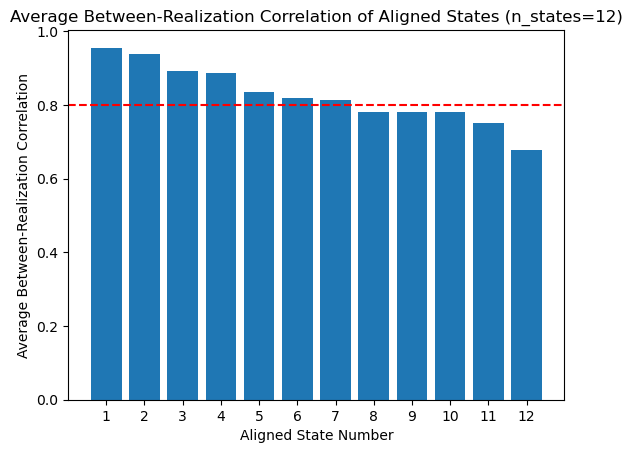


Aligned States for n_states=13:

Aligned State 1:
Realization 1, state 13
Realization 2, state 5
Realization 3, state 11
Realization 4, state 10
Realization 5, state 10
Realization 6, state 6
Realization 7, state 12
Realization 8, state 4
Realization 9, state 6
Realization 10, state 13
Average between-realization correlation: 0.9523165040899447

Aligned State 2:
Realization 1, state 2
Realization 2, state 4
Realization 3, state 13
Realization 4, state 1
Realization 5, state 5
Realization 6, state 7
Realization 7, state 8
Realization 8, state 3
Realization 9, state 11
Realization 10, state 8
Average between-realization correlation: 0.9380078466986809

Aligned State 3:
Realization 1, state 12
Realization 2, state 2
Realization 3, state 1
Realization 4, state 5
Realization 5, state 4
Realization 6, state 13
Realization 7, state 5
Realization 8, state 13
Realization 9, state 4
Realization 10, state 6
Average between-realization correlation: 0.8952994071319267

Aligned State 4:
Realization

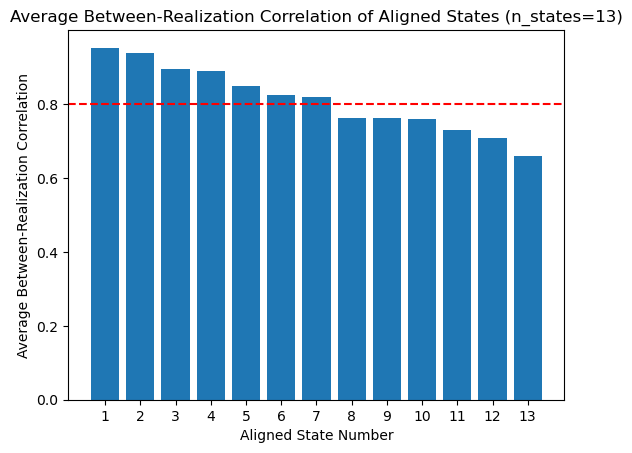


Aligned States for n_states=14:

Aligned State 1:
Realization 1, state 7
Realization 2, state 7
Realization 3, state 2
Realization 4, state 3
Realization 5, state 9
Realization 6, state 9
Realization 7, state 4
Realization 8, state 7
Realization 9, state 12
Realization 10, state 9
Average between-realization correlation: 0.9565219653250556

Aligned State 2:
Realization 1, state 2
Realization 2, state 6
Realization 3, state 10
Realization 4, state 7
Realization 5, state 11
Realization 6, state 4
Realization 7, state 6
Realization 8, state 5
Realization 9, state 5
Realization 10, state 6
Average between-realization correlation: 0.9295815472723221

Aligned State 3:
Realization 1, state 6
Realization 2, state 14
Realization 3, state 4
Realization 4, state 5
Realization 5, state 14
Realization 6, state 8
Realization 7, state 11
Realization 8, state 11
Realization 9, state 3
Realization 10, state 4
Average between-realization correlation: 0.9276302908166036

Aligned State 4:
Realization 1, 

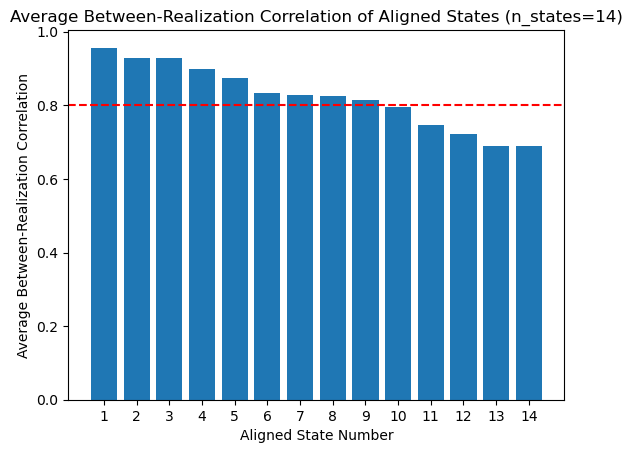


Aligned States for n_states=15:

Aligned State 1:
Realization 1, state 2
Realization 2, state 6
Realization 3, state 15
Realization 4, state 13
Realization 5, state 9
Realization 6, state 2
Realization 7, state 11
Realization 8, state 4
Realization 9, state 10
Realization 10, state 14
Average between-realization correlation: 0.9553351460366943

Aligned State 2:
Realization 1, state 5
Realization 2, state 3
Realization 3, state 5
Realization 4, state 3
Realization 5, state 14
Realization 6, state 14
Realization 7, state 12
Realization 8, state 11
Realization 9, state 7
Realization 10, state 8
Average between-realization correlation: 0.9214264610109203

Aligned State 3:
Realization 1, state 6
Realization 2, state 7
Realization 3, state 2
Realization 4, state 11
Realization 5, state 15
Realization 6, state 7
Realization 7, state 6
Realization 8, state 7
Realization 9, state 9
Realization 10, state 2
Average between-realization correlation: 0.9149537851752945

Aligned State 4:
Realization

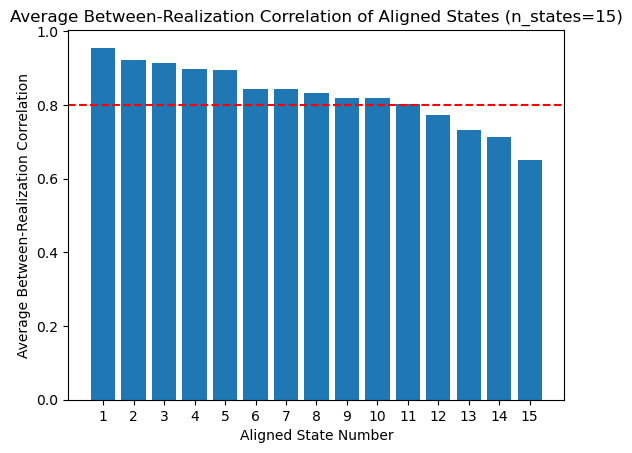


Aligned States for n_states=16:

Aligned State 1:
Realization 1, state 4
Realization 2, state 16
Realization 3, state 6
Realization 4, state 11
Realization 5, state 13
Realization 6, state 10
Realization 7, state 8
Realization 8, state 12
Realization 9, state 11
Realization 10, state 3
Average between-realization correlation: 0.9402678852484371

Aligned State 2:
Realization 1, state 14
Realization 2, state 10
Realization 3, state 5
Realization 4, state 14
Realization 5, state 15
Realization 6, state 14
Realization 7, state 11
Realization 8, state 6
Realization 9, state 14
Realization 10, state 13
Average between-realization correlation: 0.9385099028170968

Aligned State 3:
Realization 1, state 9
Realization 2, state 1
Realization 3, state 9
Realization 4, state 9
Realization 5, state 1
Realization 6, state 11
Realization 7, state 16
Realization 8, state 8
Realization 9, state 1
Realization 10, state 15
Average between-realization correlation: 0.9216350255796373

Aligned State 4:
Reali

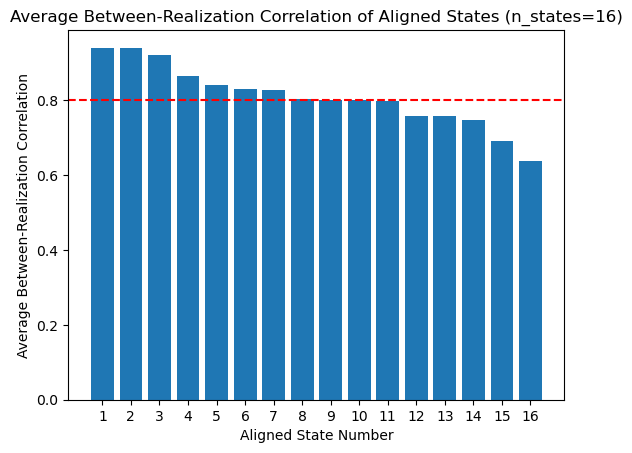


Aligned States for n_states=17:

Aligned State 1:
Realization 1, state 10
Realization 2, state 5
Realization 3, state 10
Realization 4, state 13
Realization 5, state 13
Realization 6, state 16
Realization 7, state 12
Realization 8, state 4
Realization 9, state 12
Realization 10, state 14
Average between-realization correlation: 0.9492410579208611

Aligned State 2:
Realization 1, state 12
Realization 2, state 7
Realization 3, state 4
Realization 4, state 6
Realization 5, state 14
Realization 6, state 15
Realization 7, state 2
Realization 8, state 13
Realization 9, state 8
Realization 10, state 10
Average between-realization correlation: 0.9395606861592489

Aligned State 3:
Realization 1, state 16
Realization 2, state 3
Realization 3, state 14
Realization 4, state 15
Realization 5, state 9
Realization 6, state 7
Realization 7, state 11
Realization 8, state 10
Realization 9, state 3
Realization 10, state 5
Average between-realization correlation: 0.9055763080008613

Aligned State 4:
Real

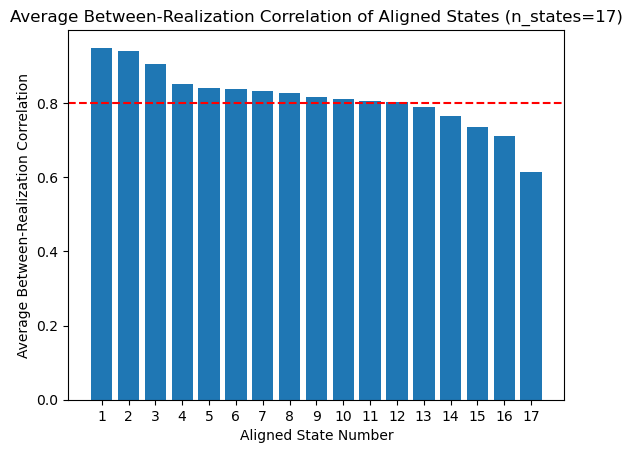


Aligned States for n_states=18:

Aligned State 1:
Realization 1, state 6
Realization 2, state 14
Realization 3, state 4
Realization 4, state 7
Realization 5, state 14
Realization 6, state 1
Realization 7, state 12
Realization 8, state 10
Realization 9, state 15
Realization 10, state 9
Average between-realization correlation: 0.9694771608877364

Aligned State 2:
Realization 1, state 1
Realization 2, state 18
Realization 3, state 16
Realization 4, state 3
Realization 5, state 3
Realization 6, state 2
Realization 7, state 6
Realization 8, state 9
Realization 9, state 10
Realization 10, state 14
Average between-realization correlation: 0.9448274990928446

Aligned State 3:
Realization 1, state 16
Realization 2, state 7
Realization 3, state 11
Realization 4, state 15
Realization 5, state 12
Realization 6, state 4
Realization 7, state 17
Realization 8, state 6
Realization 9, state 3
Realization 10, state 3
Average between-realization correlation: 0.9093965056762872

Aligned State 4:
Realizat

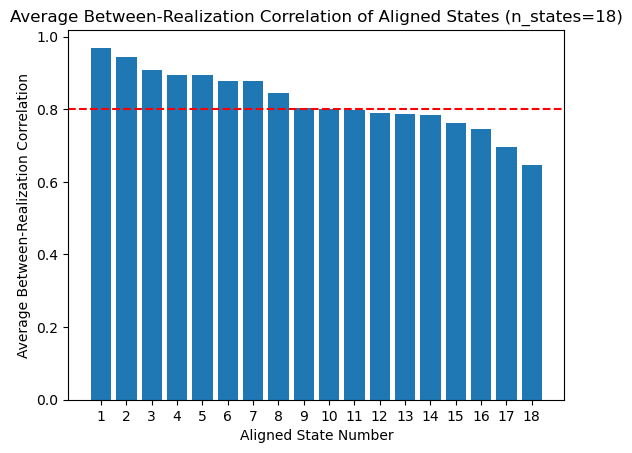


Aligned States for n_states=19:

Aligned State 1:
Realization 1, state 11
Realization 2, state 7
Realization 3, state 18
Realization 4, state 11
Realization 5, state 19
Realization 6, state 15
Realization 7, state 6
Realization 8, state 7
Realization 9, state 4
Realization 10, state 6
Average between-realization correlation: 0.9533828315118748

Aligned State 2:
Realization 1, state 16
Realization 2, state 9
Realization 3, state 19
Realization 4, state 13
Realization 5, state 11
Realization 6, state 5
Realization 7, state 1
Realization 8, state 11
Realization 9, state 12
Realization 10, state 18
Average between-realization correlation: 0.9267617208225716

Aligned State 3:
Realization 1, state 6
Realization 2, state 13
Realization 3, state 13
Realization 4, state 2
Realization 5, state 16
Realization 6, state 7
Realization 7, state 2
Realization 8, state 14
Realization 9, state 6
Realization 10, state 5
Average between-realization correlation: 0.9151645250956575

Aligned State 4:
Realiz

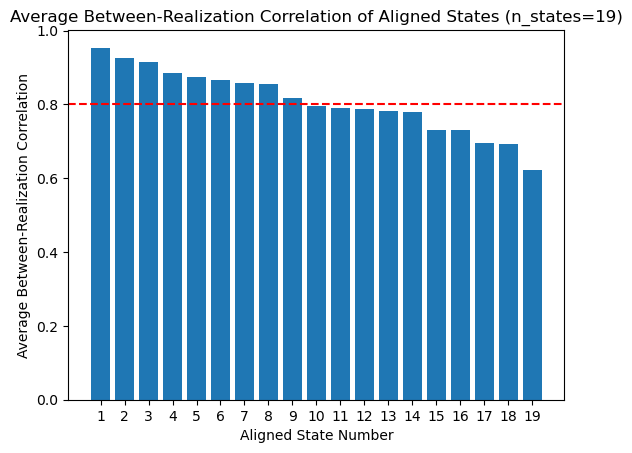


Aligned States for n_states=20:

Aligned State 1:
Realization 1, state 13
Realization 2, state 3
Realization 3, state 19
Realization 4, state 5
Realization 5, state 20
Realization 6, state 10
Realization 7, state 18
Realization 8, state 3
Realization 9, state 20
Realization 10, state 10
Average between-realization correlation: 0.9521122285091896

Aligned State 2:
Realization 1, state 17
Realization 2, state 5
Realization 3, state 16
Realization 4, state 12
Realization 5, state 9
Realization 6, state 8
Realization 7, state 5
Realization 8, state 1
Realization 9, state 5
Realization 10, state 17
Average between-realization correlation: 0.9439308861600335

Aligned State 3:
Realization 1, state 18
Realization 2, state 7
Realization 3, state 8
Realization 4, state 18
Realization 5, state 12
Realization 6, state 7
Realization 7, state 14
Realization 8, state 17
Realization 9, state 4
Realization 10, state 9
Average between-realization correlation: 0.888553288117847

Aligned State 4:
Realiza

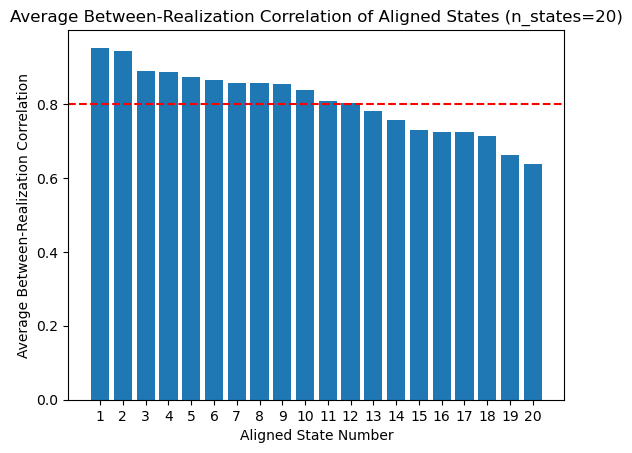

In [23]:
for num_states in sorted_states:
    CRCM = np.zeros(shape=(num_states * num_realizations, num_states * num_realizations))
    for i in range(num_realizations):
        for j in range(num_realizations):
            if i != j:
                CRCM[i * num_states:(i * num_states) + num_states, j * num_states:(j * num_states) + num_states] = abs(realization_corr(
                    model_eval_log[num_states]['realizations'][i]['off_diags'], 
                    model_eval_log[num_states]['realizations'][j]['off_diags']
                ))

    state_groups = [] # [(realization number, state number), ...] using 1-based indexing for realization and state numbers for interpretability
    while np.max(CRCM) > 0:
        state_groups.append([])
        m, n = np.unravel_index(np.argmax(CRCM), shape=CRCM.shape)
        state_groups[-1].append((int(m // num_states + 1), int(m % num_states + 1)))
        state_groups[-1].append((int(n // num_states + 1), int(n % num_states + 1)))
        for i in range(num_realizations):
            if i != m // num_states and i != n // num_states:
                p_i = i * num_states + np.argmax(CRCM[m, i * num_states:(i * num_states) + num_states])
                q_i = i * num_states + np.argmax(CRCM[i * num_states:(i * num_states) + num_states, n])
                if p_i == q_i or CRCM[m, p_i] > CRCM[q_i, n]:
                    state_groups[-1].append((i + 1, int(p_i % num_states + 1)))
                    CRCM[:, p_i] = 0
                    CRCM[p_i, :] = 0
                else:
                    state_groups[-1].append((i + 1, int(q_i % num_states + 1)))
                    CRCM[q_i, :] = 0
                    CRCM[:, q_i] = 0
    
        CRCM[m, :] = 0
        CRCM[:, m] = 0
        CRCM[:, n] = 0
        CRCM[n, :] = 0

    within_group_avg_corrs = []
    for g in range(len(state_groups)):
        off_diags = []
        within_group_corrs = []
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            off_diags.append(model_eval_log[num_states]['realizations'][r - 1]['off_diags'][:, s - 1]) # r and s use 1-based indexing, so must subtract 1
            
        for i in range(len(off_diags)):
            for j in range(i + 1, len(off_diags)):
                within_group_corrs.append(np.corrcoef(off_diags[i], off_diags[j]))
    
        within_group_avg_corr = np.mean(within_group_corrs)
        within_group_avg_corrs.append(within_group_avg_corr)

    idx_seq = []
    for i, corr in sorted(enumerate(within_group_avg_corrs), key=lambda x: x[1], reverse=True):
        idx_seq.append(i)

    # Reorder state_groups and within_group_avg_corrs in order of decreasing average between-realization correlation
    state_groups = [state_groups[i] for i in idx_seq]
    within_group_avg_corrs = [within_group_avg_corrs[i] for i in idx_seq]
    print(f"\nAligned States for n_states={num_states}:")
    for g in range(len(state_groups)):
        print(f"\nAligned State {g + 1}:")
        for r, s in sorted(state_groups[g], key=lambda r: r[0]):
            print(f"Realization {r}, state {s}")
    
        print(f"Average between-realization correlation: {within_group_avg_corrs[g]}")

    plt.bar(
        [str(i) for i in range(1, len(state_groups) + 1)],
        within_group_avg_corrs,
    )
    plt.axhline(y=0.8, color='r', linestyle='--') # stability threshold
    
    plt.title(f"Average Between-Realization Correlation of Aligned States (n_states={num_states})")
    plt.xlabel("Aligned State Number")
    plt.ylabel("Average Between-Realization Correlation")
    plt.show()

# Fit Best Model and Compute Summary Statistics

In [24]:
optimal_num_states = 12
model = load(model_eval_log[optimal_num_states]['best_realization_path'])

In [25]:
inf_params_path = f'{results_path}/{optimal_num_states}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [26]:
alpha_path = f'{inf_params_path}/alp_{optimal_num_states}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

Getting alpha:   0%|          | 0/58 [00:00<?, ?it/s]

In [27]:
# We first work with the dual-estimated means and covs
dual_estimates_path = f'{results_path}/{optimal_num_states}_states/dual_estimates'
if os.path.exists(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy') and os.path.exists(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy'):
    means, covs = np.load(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy'), np.load(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy')
else:  
    means, covs = model.dual_estimation(full_data, alpha=alpha)
    os.makedirs(dual_estimates_path, exist_ok=True) 
    np.save(f'{dual_estimates_path}/means_{optimal_num_states}_states.npy', means)
    np.save(f'{dual_estimates_path}/covs_{optimal_num_states}_states.npy', covs)

print(means.shape)
print(covs.shape)

Dual estimation:   0%|          | 0/58 [00:00<?, ?it/s]

(12, 17)
(58, 12, 17, 17)


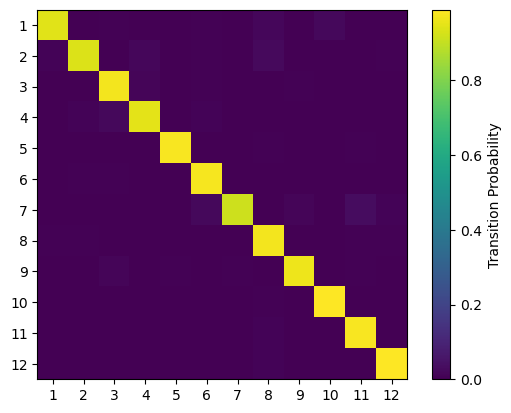

In [28]:
trans_matrix = model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.yticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [29]:
# Now the group-level means and covs
means, covs = model.get_means_covariances()
means.shape, covs.shape

((12, 17), (12, 17, 17))

In [30]:
np.save(f"{inf_params_path}/means_{optimal_num_states}_states.npy", means)
np.save(f"{inf_params_path}/covs_{optimal_num_states}_states.npy", covs)

In [31]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 58)

In [32]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = modes.argmax_time_courses(alpha) # state time course

In [33]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(58, 12)

In [34]:
# FO of each state averaged across subjects
np.mean(fo, axis=0)

array([0.04628352, 0.05992337, 0.121341  , 0.06226054, 0.06103448,
       0.08869732, 0.03229885, 0.16517241, 0.0464751 , 0.08318008,
       0.0951341 , 0.13819923])

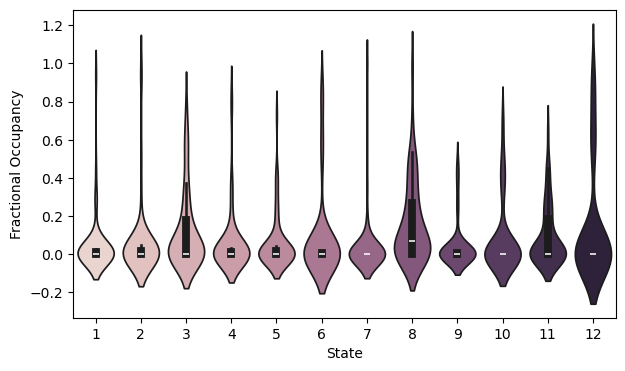

In [35]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

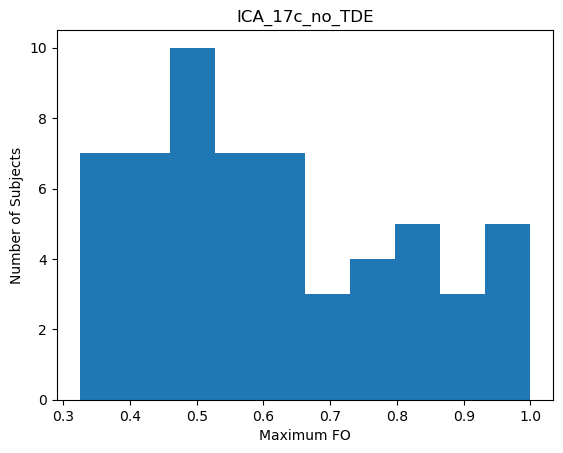

In [36]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(pkl_suffix)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [37]:
# Mean maxFOs for each experimental group
for group in np.unique(y):
    print(f"{group}:", np.mean(np.max(fo[np.where(y == group)[0],], axis=1)))

r13_PID1: 0.6775
r13_PID7: 0.6286111111111111
shm_PID1: 0.5890909090909091
shm_PID7: 0.5872727272727274
veh_PID1: 0.6666666666666666
veh_PID7: 0.5704444444444444


In [39]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

r13_03mc_PID1
r13_05fd_PID7
r13_05mb_PID1
r13_05mb_PID7
shm_03mb_PID1
veh_04ma_PID1
veh_04mc_PID1


7

## Subject-Level State Time Courses (Viterbi Paths)

### PID1

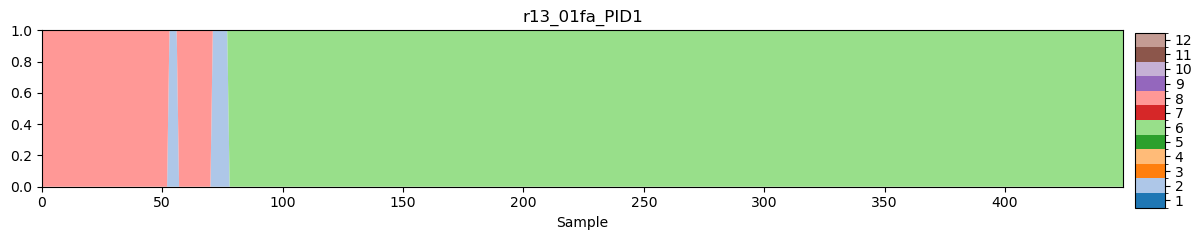

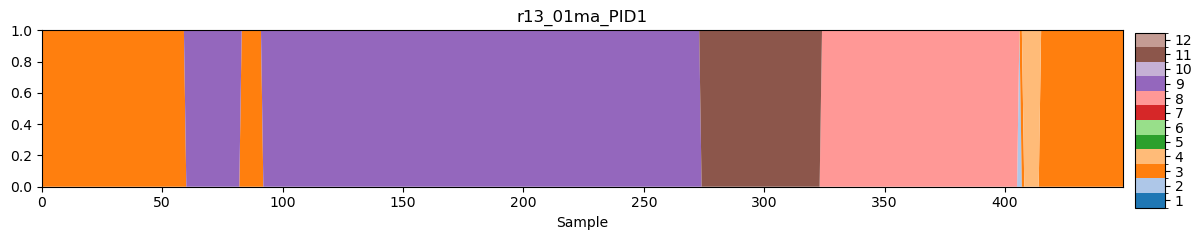

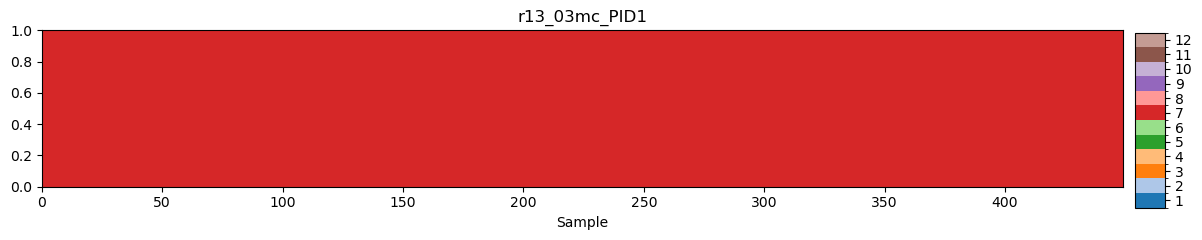

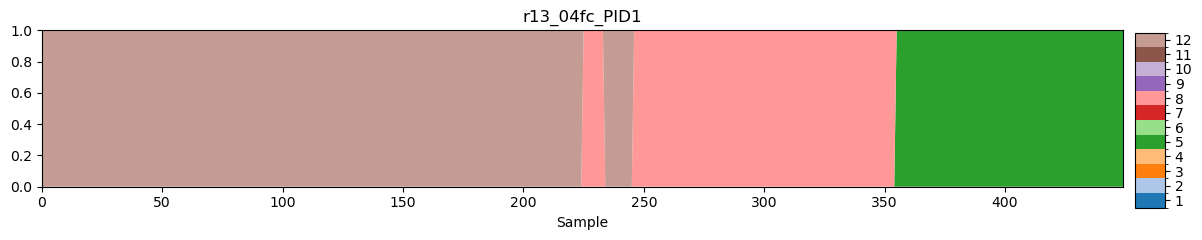

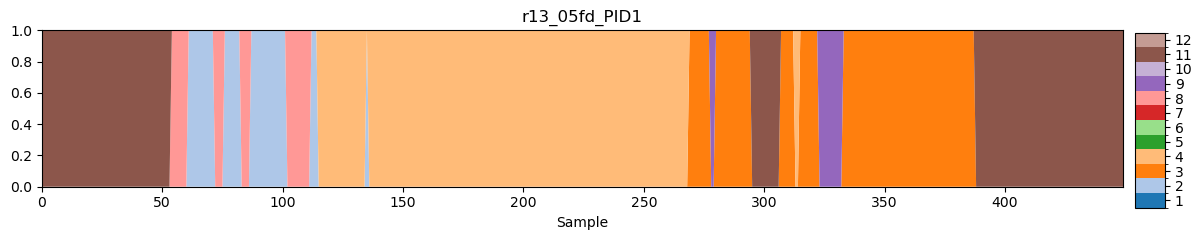

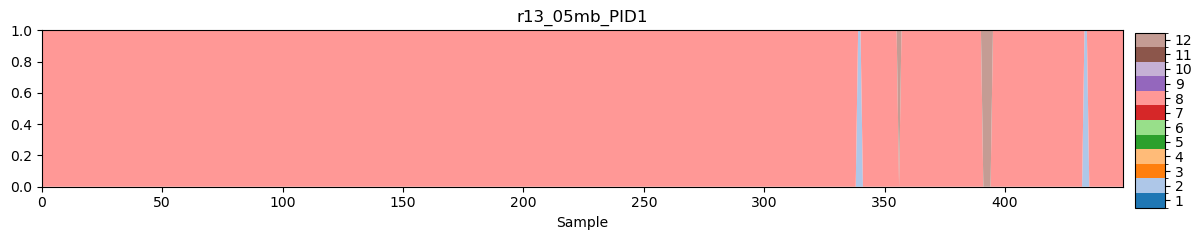

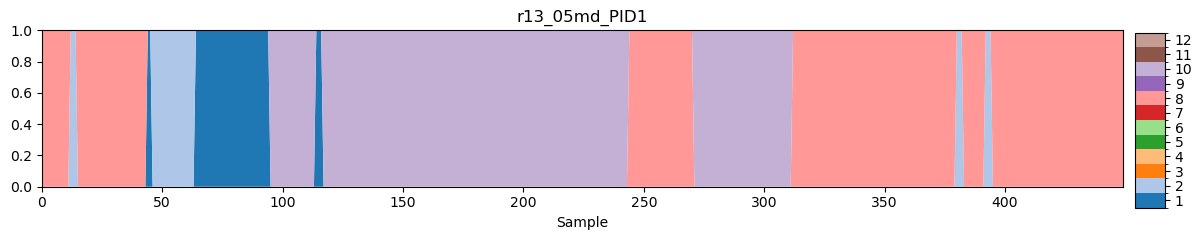

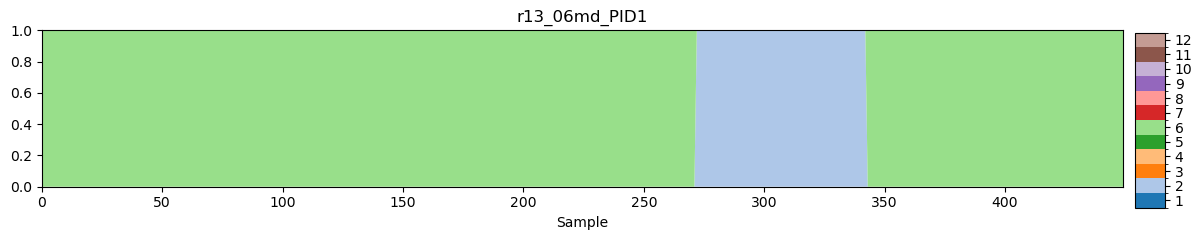

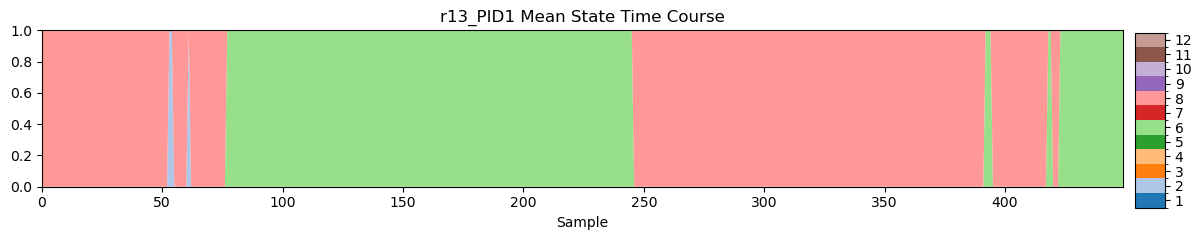

In [40]:
# r13_PID1
for subj in np.where(y == 'r13_PID1')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'r13_PID1')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="r13_PID1 Mean State Time Course")

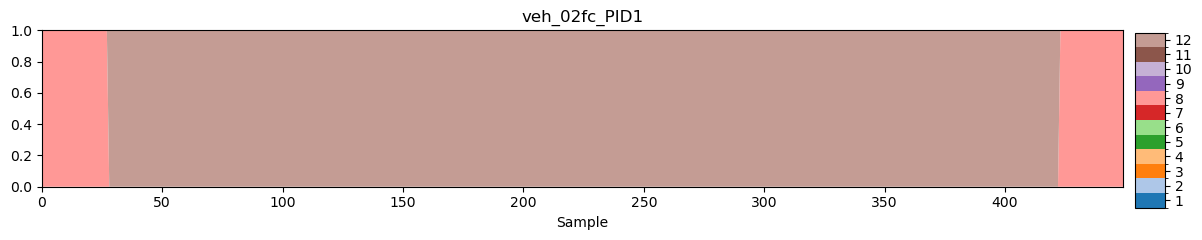

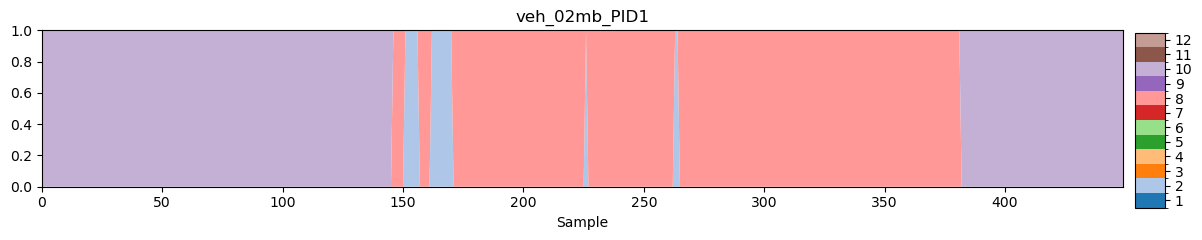

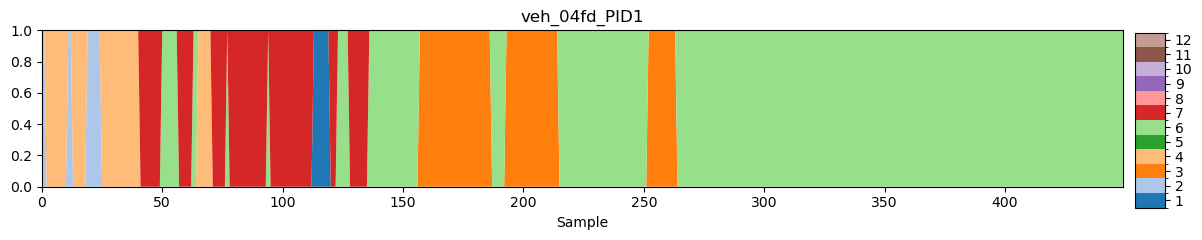

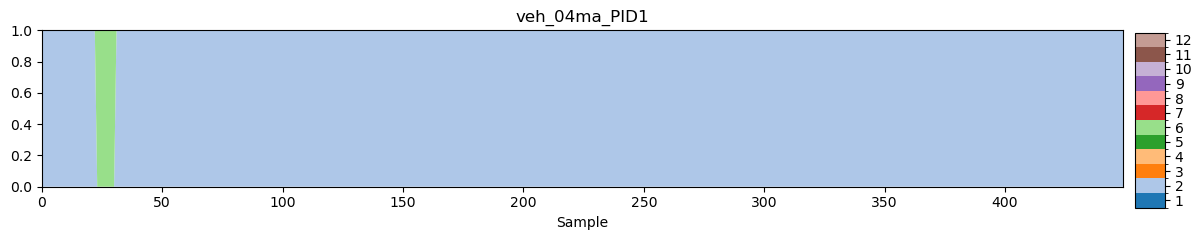

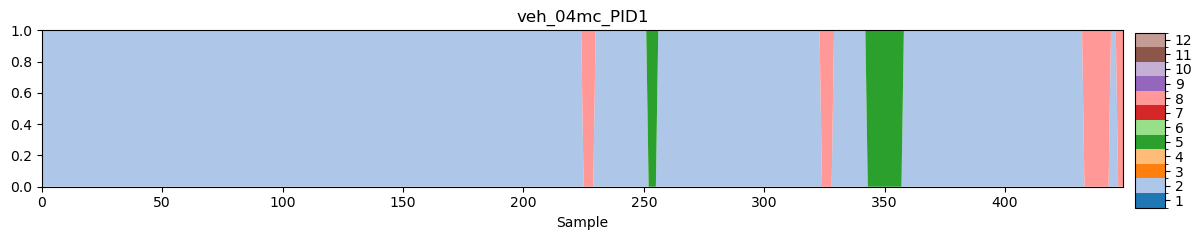

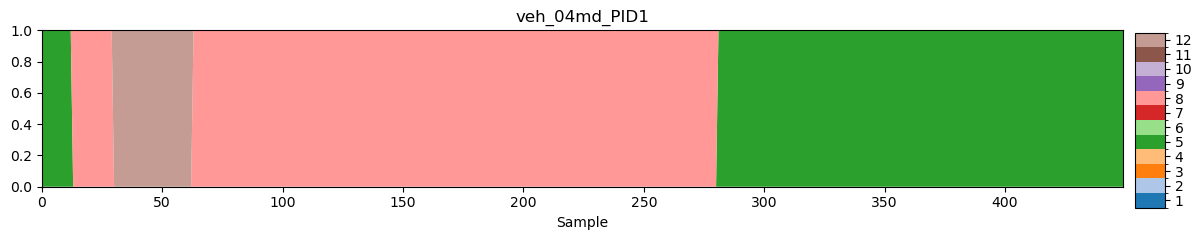

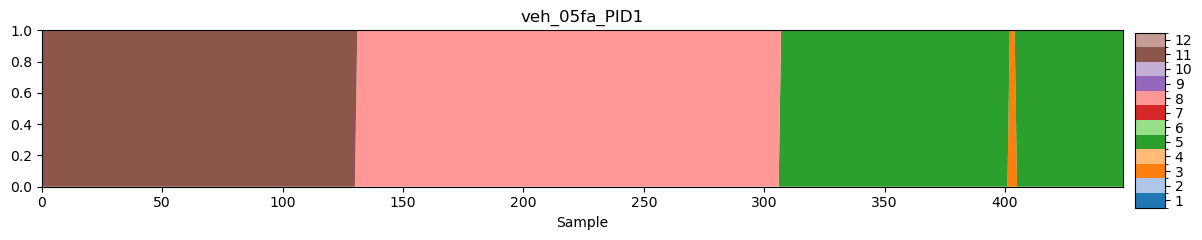

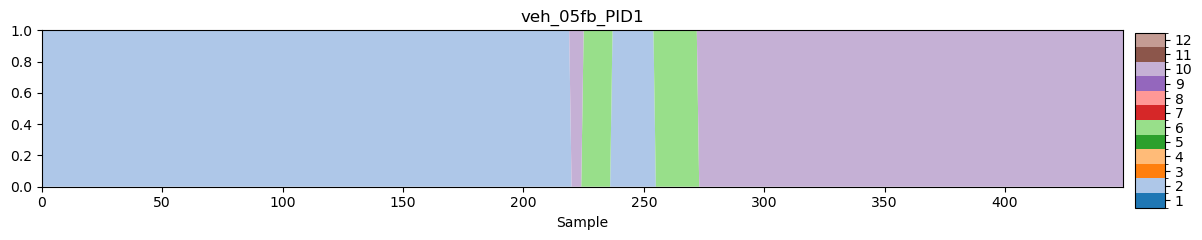

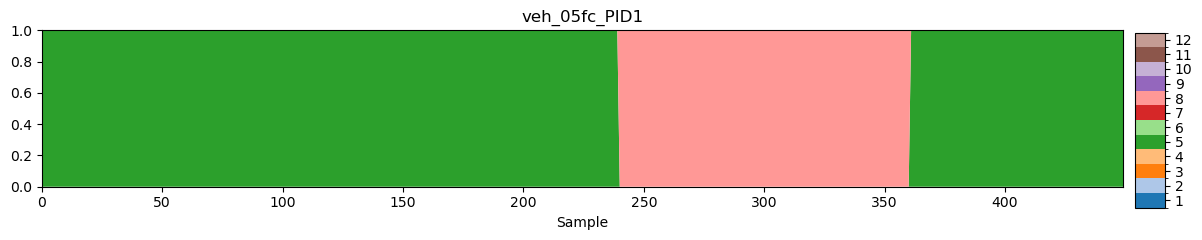

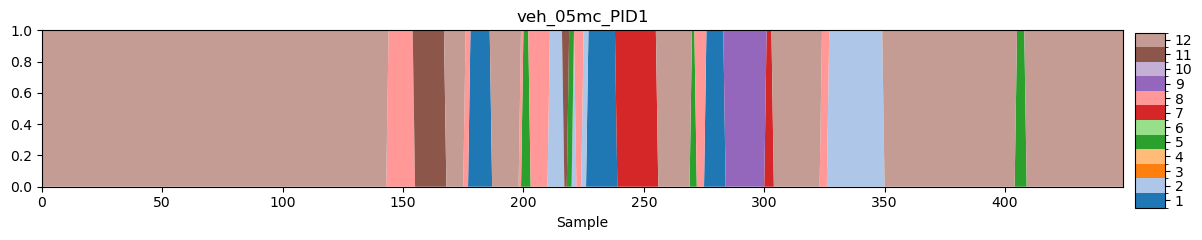

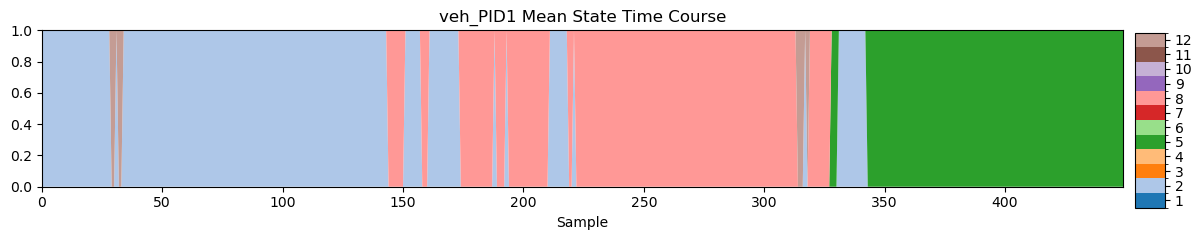

In [41]:
# veh_PID1
for subj in np.where(y == 'veh_PID1')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'veh_PID1')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="veh_PID1 Mean State Time Course")

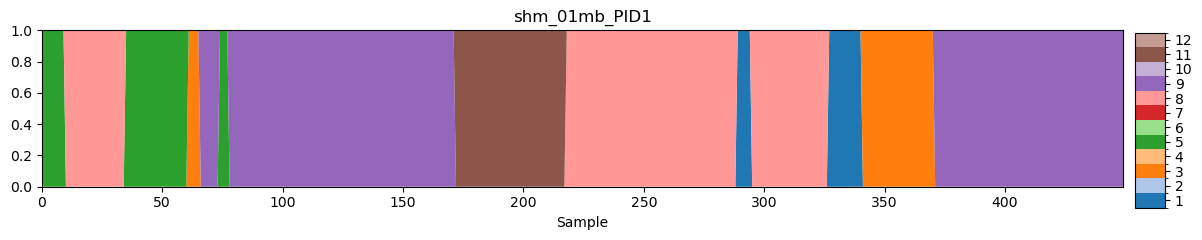

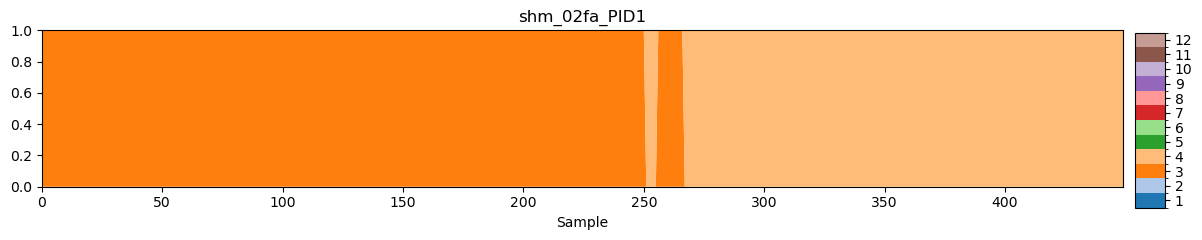

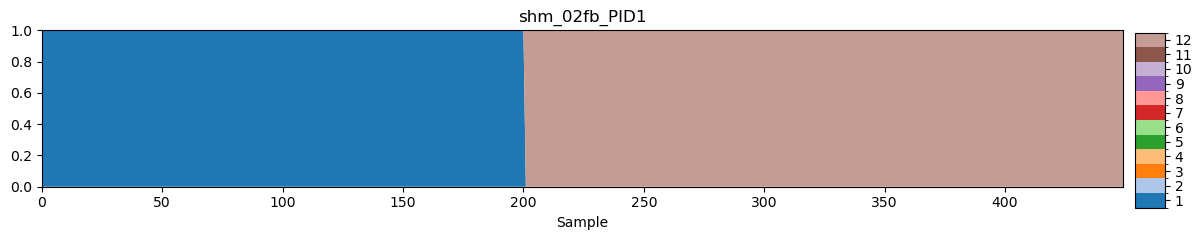

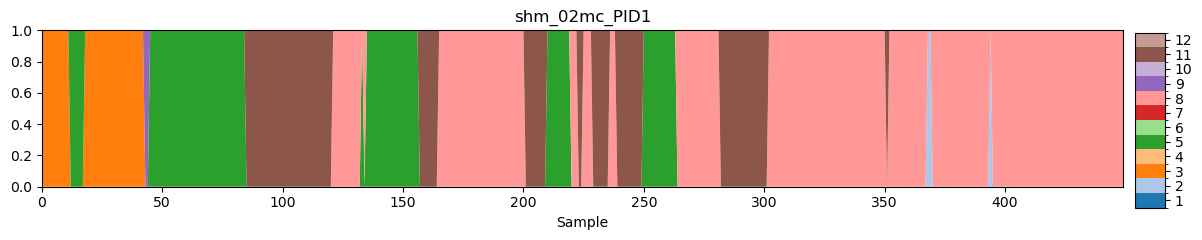

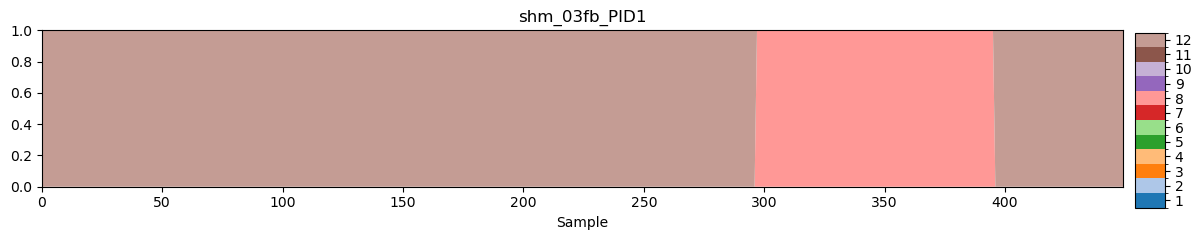

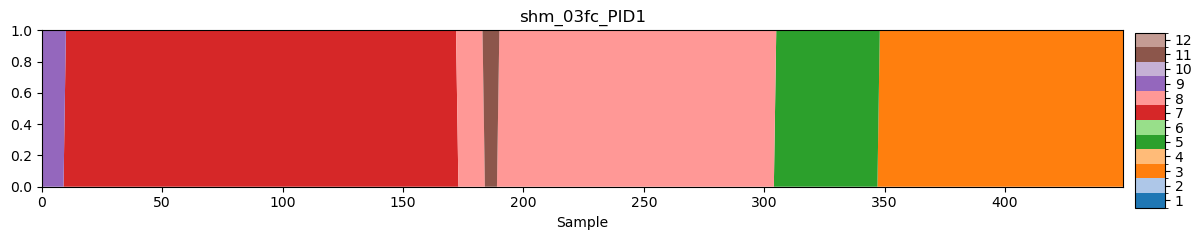

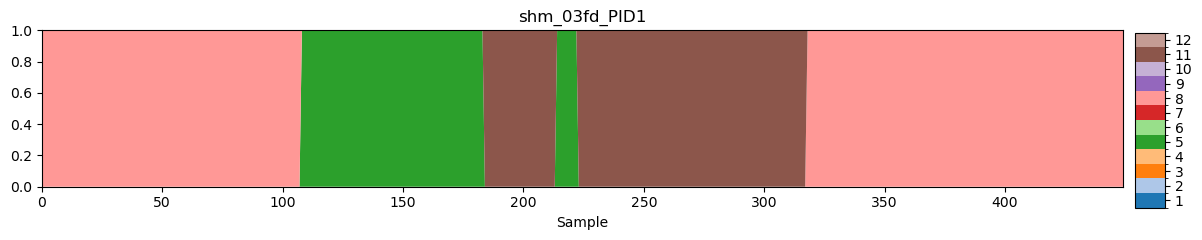

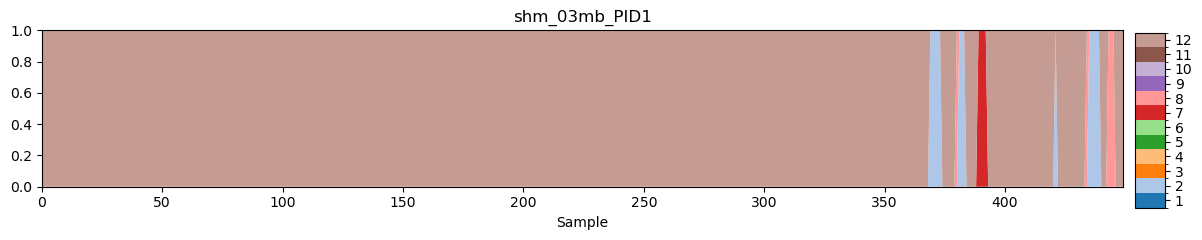

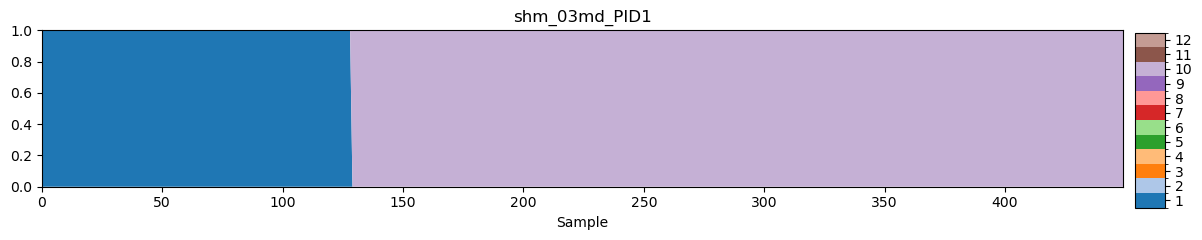

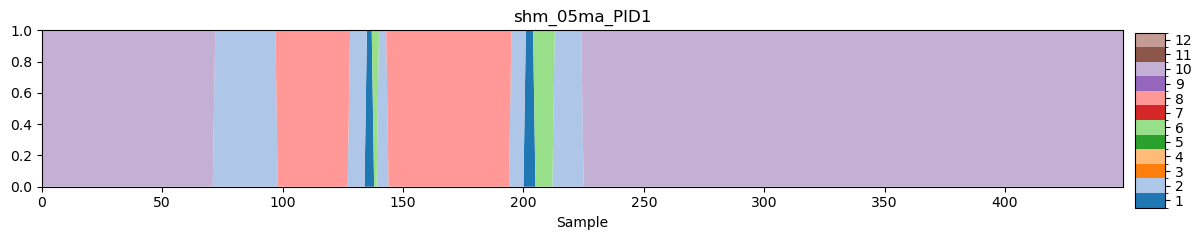

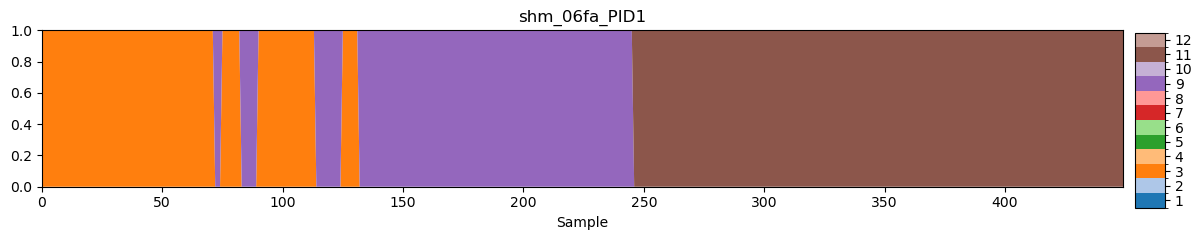

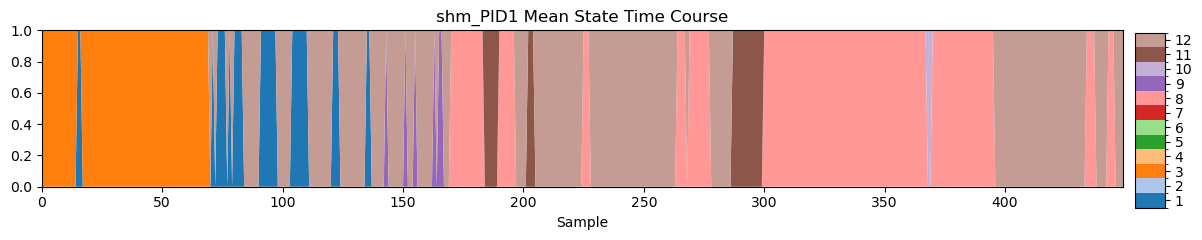

In [42]:
# shm_PID1
for subj in np.where(y == 'shm_PID1')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'shm_PID1')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="shm_PID1 Mean State Time Course")

### PID7

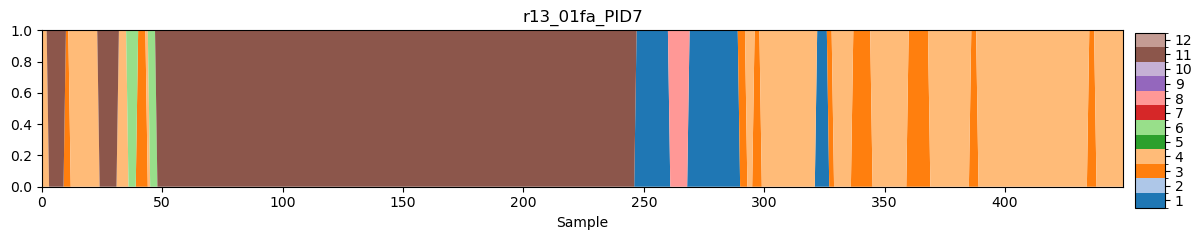

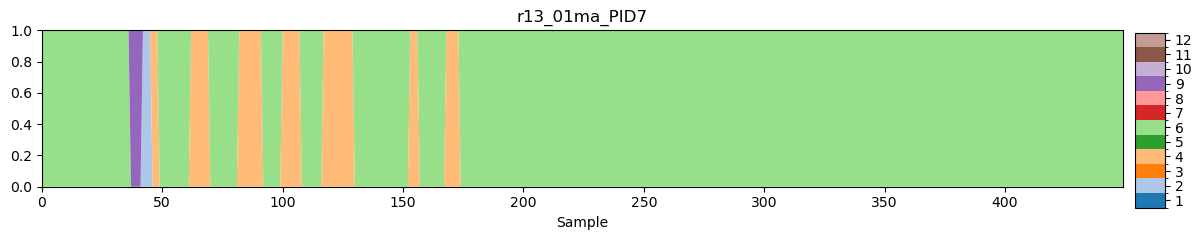

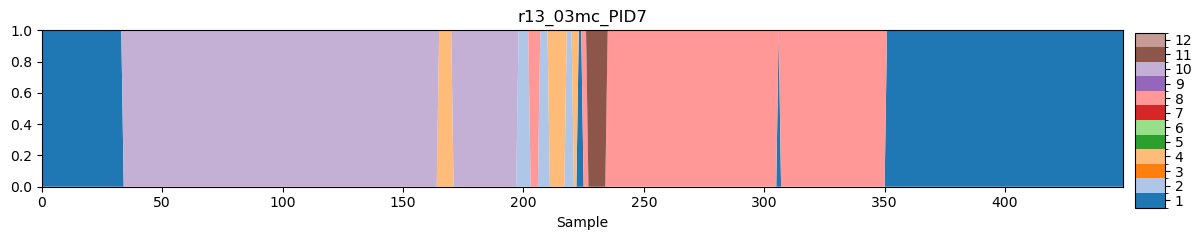

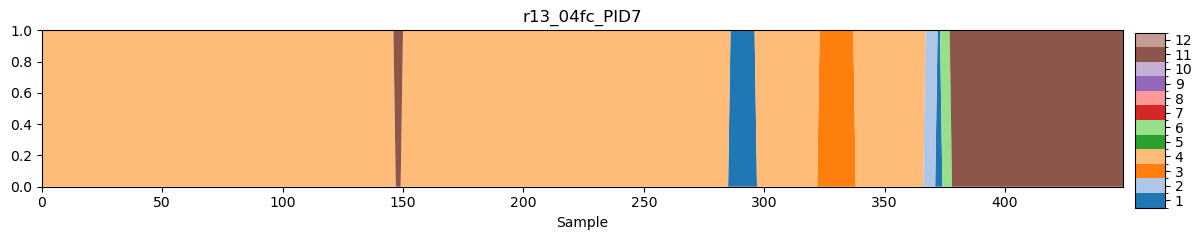

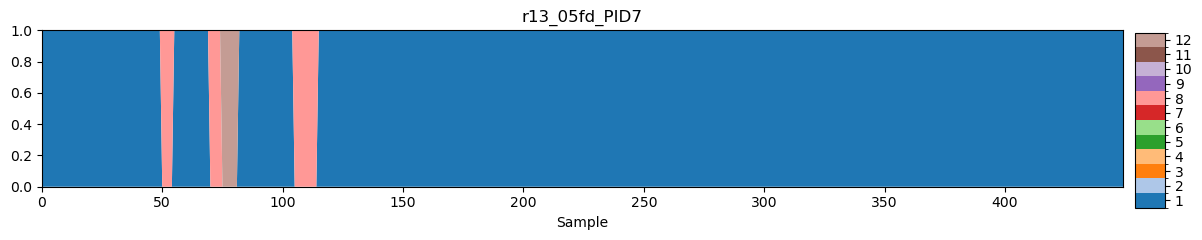

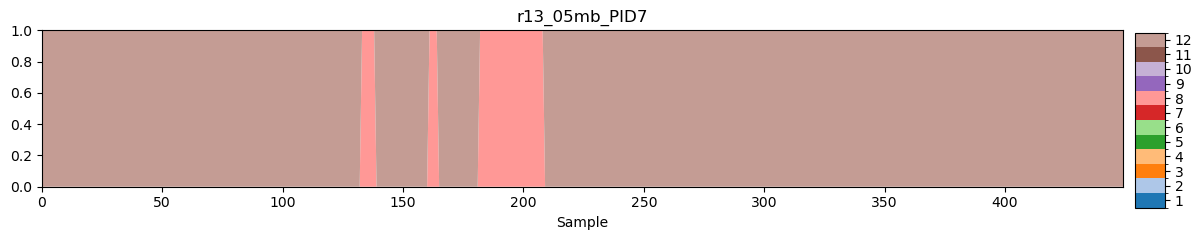

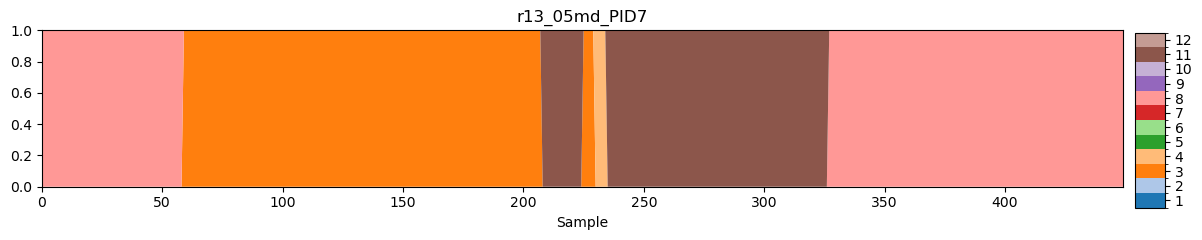

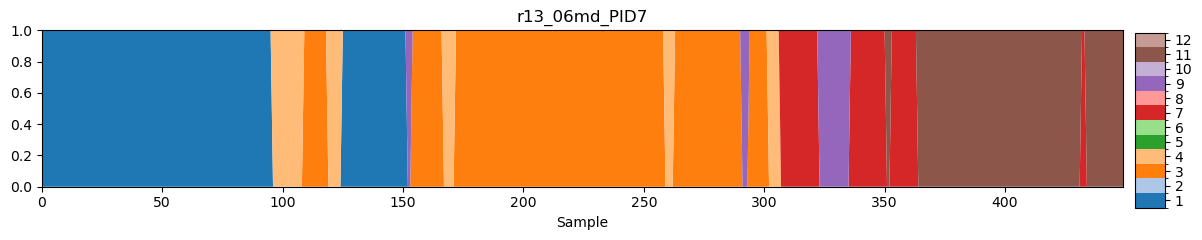

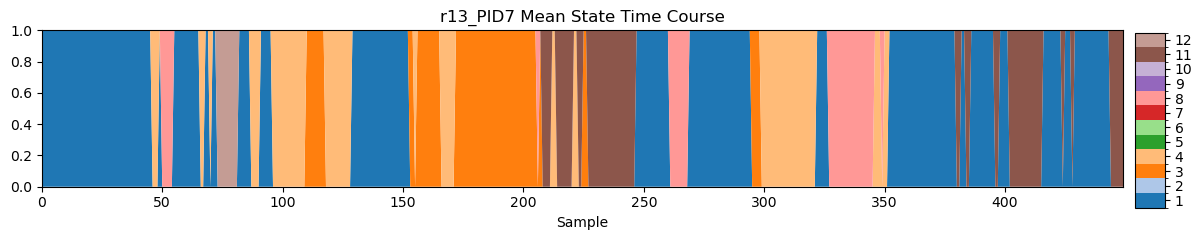

In [43]:
# r13_PID7
for subj in np.where(y == 'r13_PID7')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'r13_PID7')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="r13_PID7 Mean State Time Course")

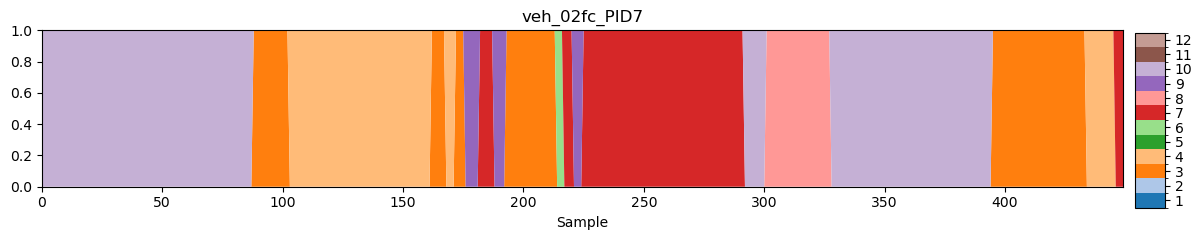

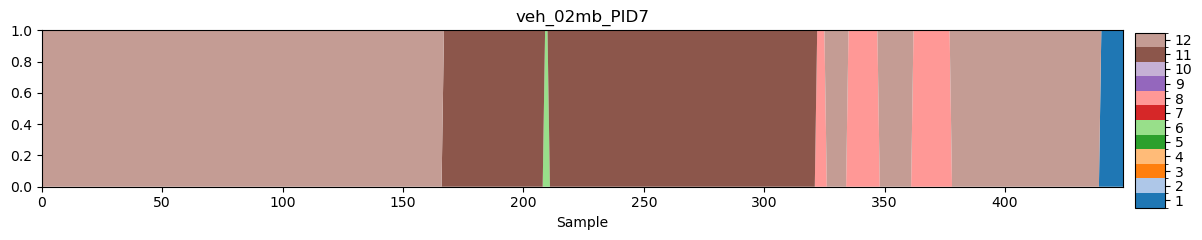

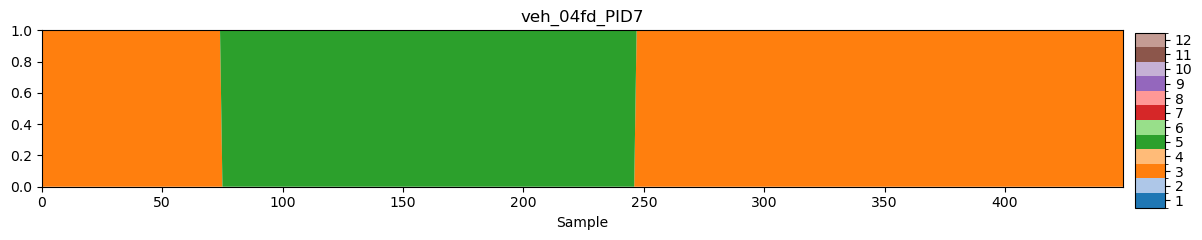

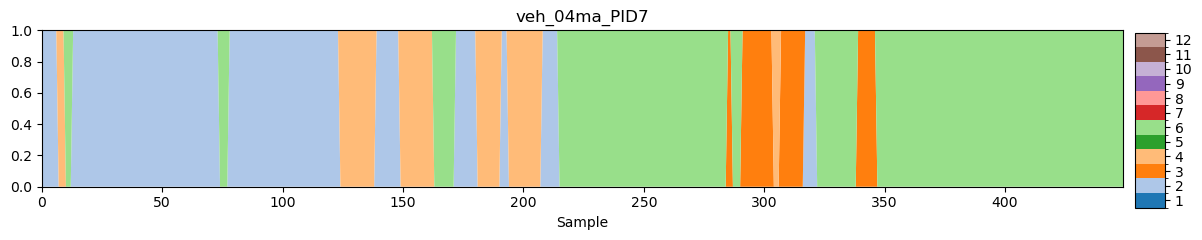

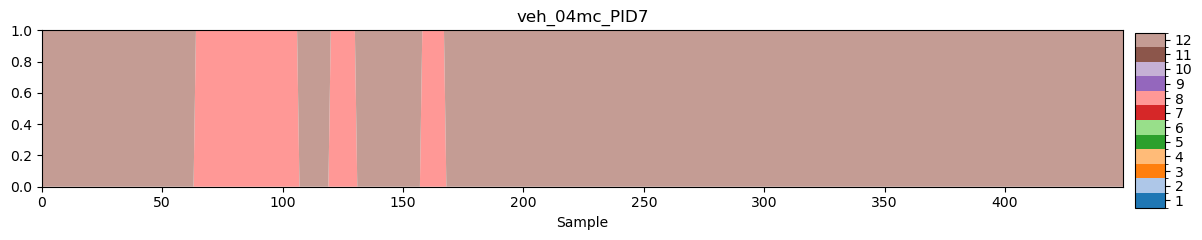

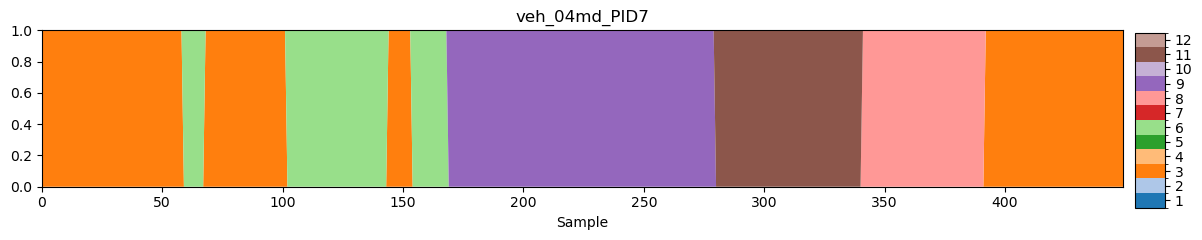

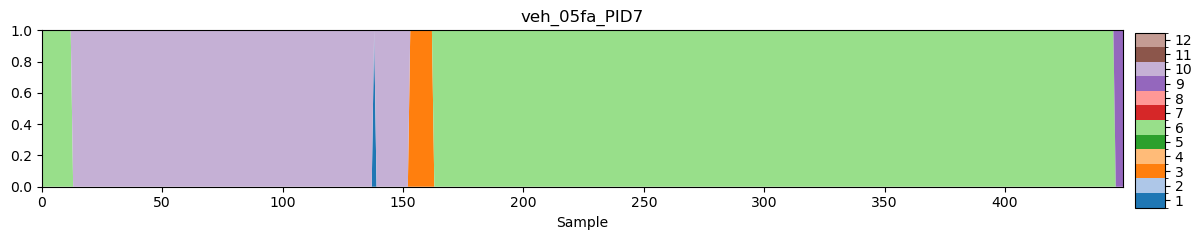

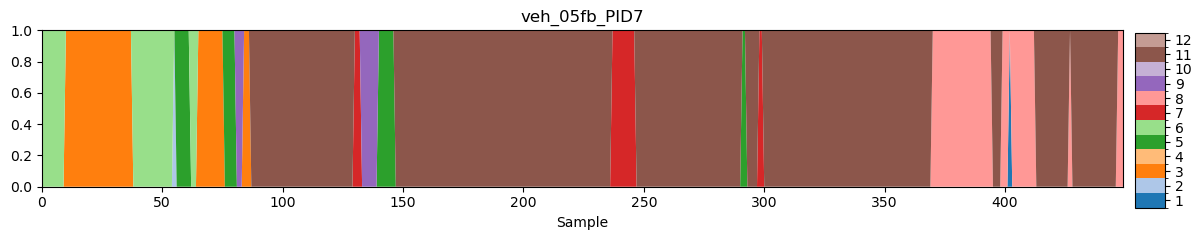

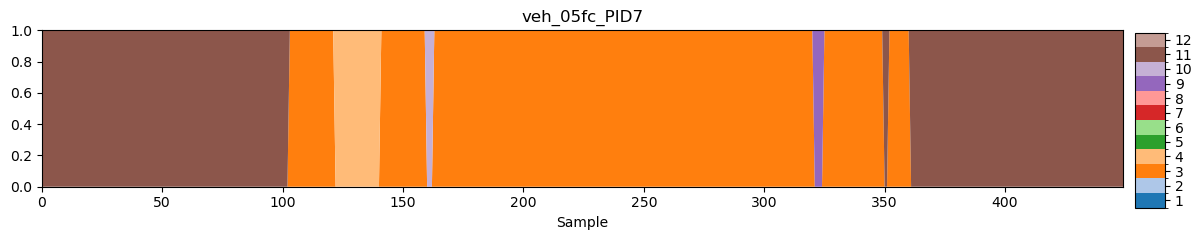

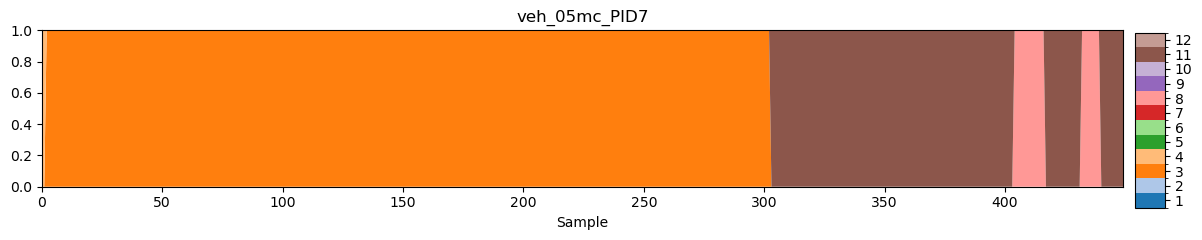

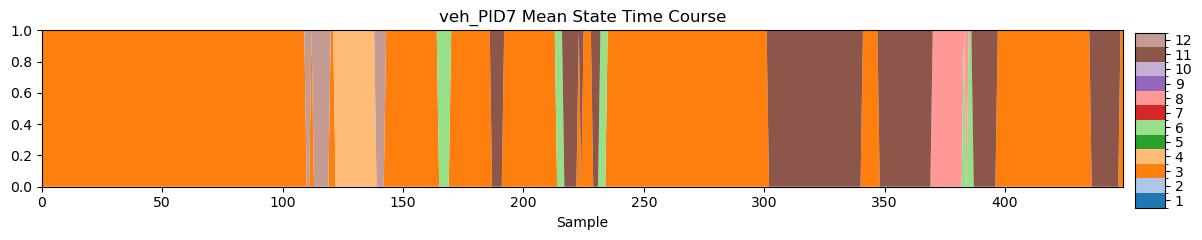

In [44]:
# veh_PID7
for subj in np.where(y == 'veh_PID7')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'veh_PID7')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="veh_PID7 Mean State Time Course")

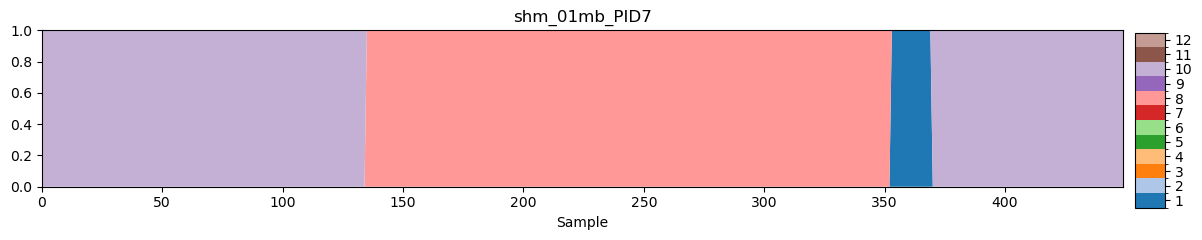

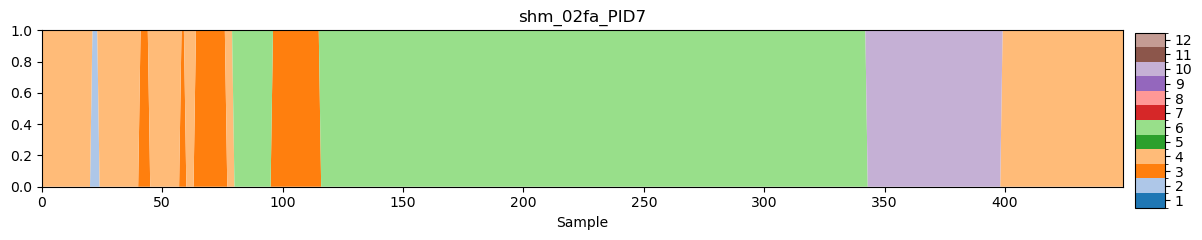

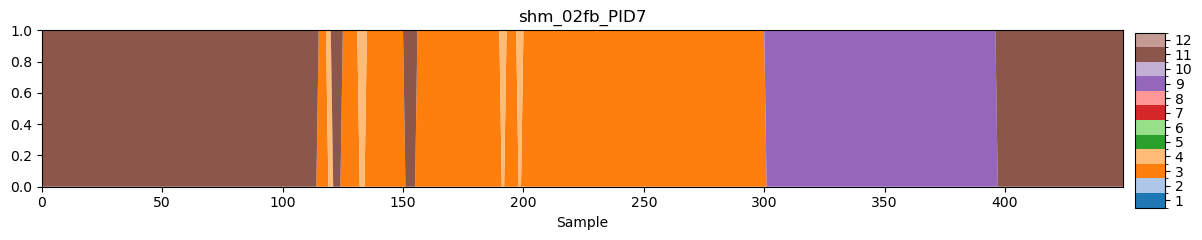

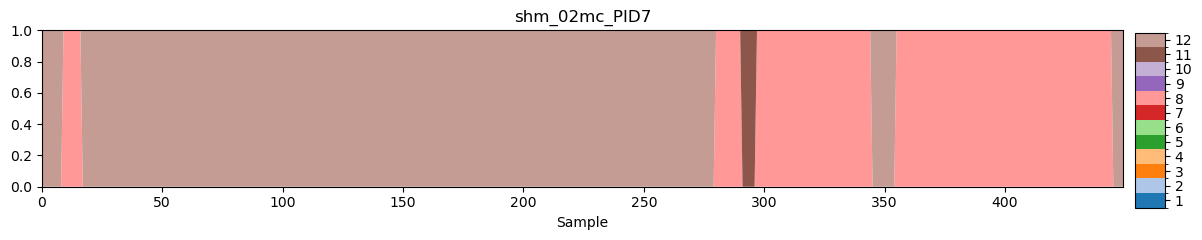

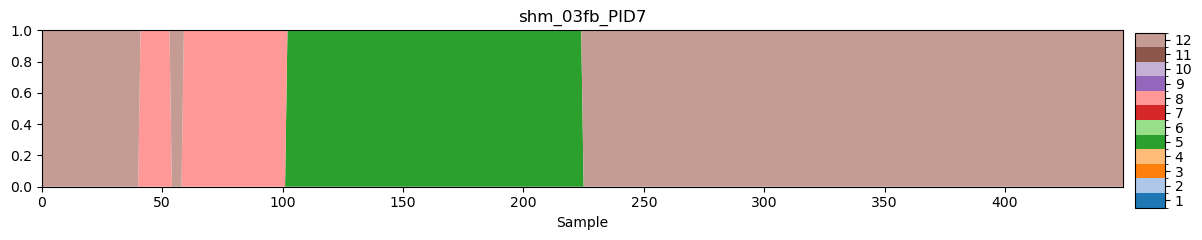

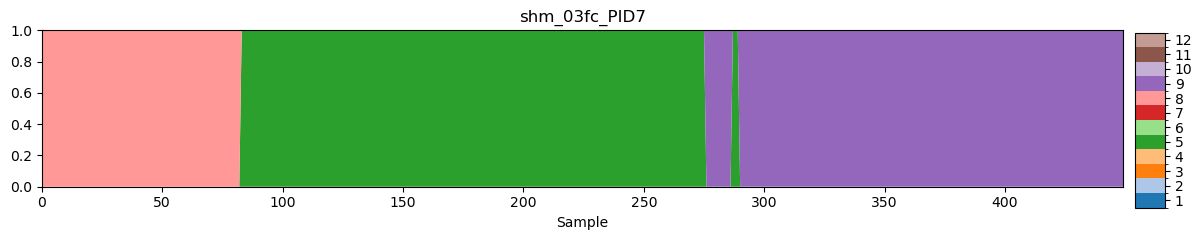

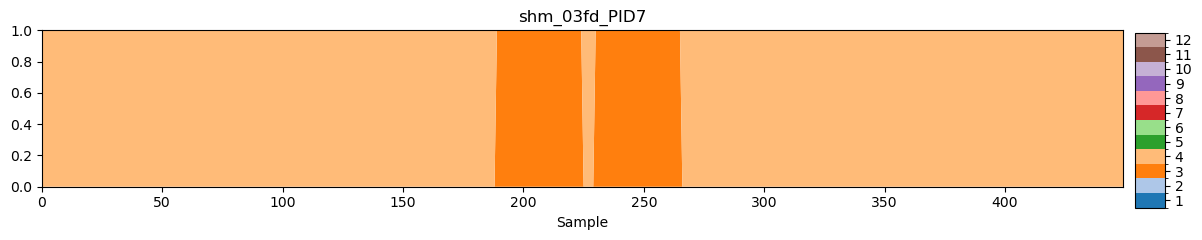

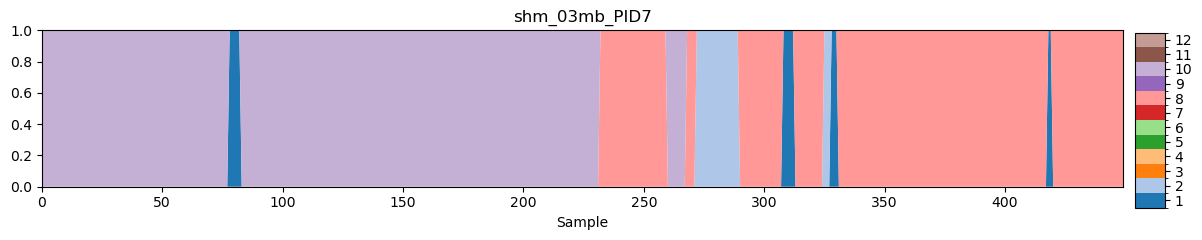

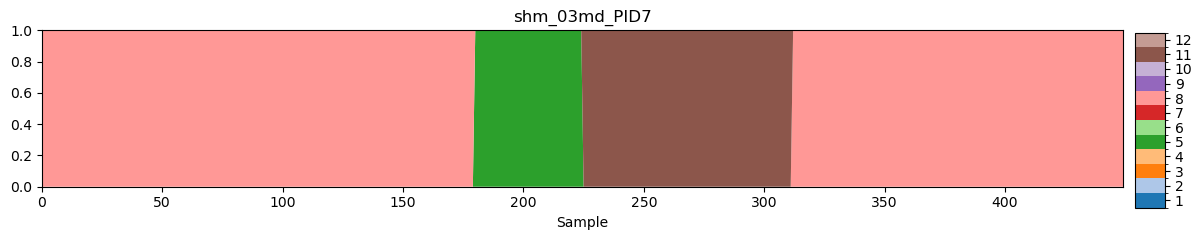

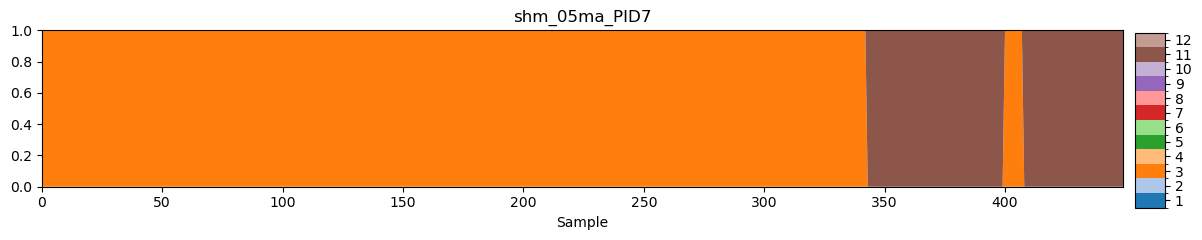

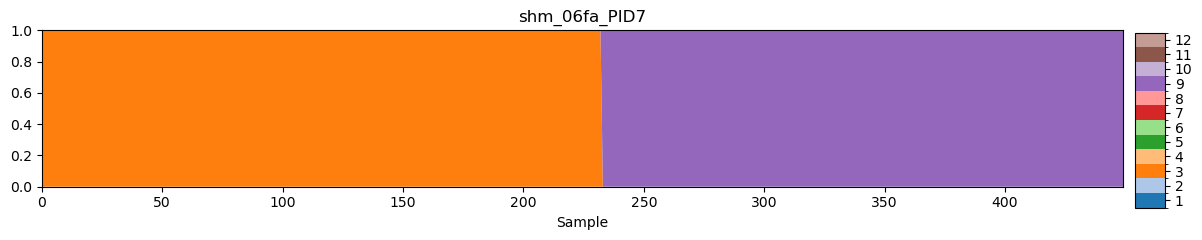

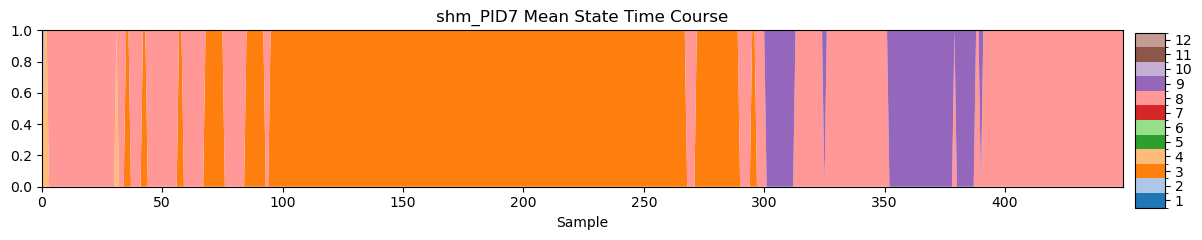

In [45]:
# shm_PID7
for subj in np.where(y == 'shm_PID7')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj]))

group_mean = modes.argmax_time_courses(np.mean(np.array(alpha)[np.where(y == 'shm_PID7')[0]], axis=0))
fig, ax = plotting.plot_alpha(group_mean, n_samples=X.shape[1], cmap='tab20', title="shm_PID7 Mean State Time Course")